# **Spectral Methods**

# Transformasi Fourier Diskrit (Discrete Fourier Transform / DFT)

Misalkan kita punya barisan $N$ buah nilai $y_n$ (dengan $n = 1, \ldots, N$) yang bisa berupa bilangan biasa maupun bilangan kompleks.

Transformasi Fourier Diskrit (DFT) mengubah barisan tersebut menjadi barisan baru $Y_m$ (dengan $m = 1, \ldots, N$) menggunakan rumus:

$$
Y_m = \sum^N_{n=1} y_n \, e^{-2\pi i(m-1)(n-1)/N}
$$

Sederhananya: DFT memecah sinyal/data asli menjadi **komponen-komponen frekuensi** penyusunnya — mirip seperti prisma yang memecah cahaya putih menjadi pelangi.


## Transformasi Balik (Inverse DFT)

Transformasi Balik adalah kebalikannya — mengubah komponen frekuensi $Y_m$ kembali menjadi data asli $y_n$:

$$
y_n = \frac{1}{N} \sum^N_{m=1} Y_m \, e^{2\pi i(m-1)(n-1)/N}
$$

> Catatan: Perhatikan ada pembagi $\frac{1}{N}$ dan tanda eksponen yang berlawanan arah (positif). Itulah perbedaan utamanya dari rumus maju.


Penggunaan langsung rumus-rumus ini membutuhkan $\mathcal{O}(N^2)$ operasi untuk melakukan satu transformasi. Namun, jika $N = 2^k$ untuk suatu $k \in \mathbb{Z^+}$, salah satu keajaiban komputasi modern — Fast Fourier Transform (FFT) — dapat digunakan, yang hanya membutuhkan $\mathcal{O}(N \log N)$ operasi. Hal ini dapat digeneralisasi (dengan membagi domain menjadi jumlah titik yang sesuai) tanpa kehilangan kecepatan secara umum. Karena FFT sudah sangat umum digunakan, kebanyakan orang menyebut FFT sebagai pengganti DFT ketika mendeskripsikan suatu pendekatan.


#### Hubungan dengan Analisis Fourier

Salah satu sudut pandang yang bisa kita ambil untuk merumuskan **metode spektral** adalah kita ingin merekonstruksi/menguraikan fungsi periodik $y(x)$ dengan panjang gelombang $L$, berdasarkan nilainya pada himpunan diskrit dari $N$ titik yang berjarak sama:

$$
x_n = \frac{(n-1) L}{N}
$$

Perhatikan koefisien Fourier dari fungsi $y(x)$:

$$
\hat{y}_m = \frac{1}{L} \int^L_0 y(x) \exp(-i k(m) x) \, dx, \quad m = 0, \pm 1, \pm 2, \ldots
$$

di mana ilangan gelombang (wave number) yang terkait dengan koefisien Fourier ke-$m$ adalah:

$$
k(m) = \frac{2\pi m}{L}
$$

Dari koefisien-koefisien ini, kita dapat merekonstruksi fungsi $y(x)$ kembali sebagai:

$$
y(x) = \sum^\infty_{m=-\infty} \hat{y}_m \exp(i k(m) x)
$$

 Bayangkan fungsi $y(x)$ sebagai sebuah lagu. Lagu tersebut sebenarnya tersusun dari banyak nada (frekuensi) yang berbeda-beda yang dimainkan secara bersamaan.

- Koefisien Fourier $\hat{y}_m$ — adalah "seberapa kuat" nada ke-$m$ dalam lagu tersebut. Dihitung dengan cara mengintegralkan (merata-ratakan) fungsi terhadap setiap frekuensi.
 - Bilangan gelombang $k(m)$ — menentukan "seberapa cepat" suatu gelombang berosilasi. Semakin besar $m$, semakin tinggi frekuensinya.
 - Rekonstruksi — jika kita sudah tahu semua koefisien $\hat{y}_m$, kita bisa menjumlahkan kembali seluruh nada tersebut untuk mendapatkan lagu aslinya secara sempurna.


Ingat bahwa koefisien $\hat{y}_m \rightarrow 0$ ketika $m \rightarrow \infty$. Secara khusus, jika $y(x) \in C^R$ pada seluruh interval $[0, L]$, maka koefisien Fourier meluruh sebesar $\mathcal{O}(|m|^{-(R+1)})$. Artinya, semakin "mulus" suatu fungsi (semakin besar $R$), koefisien Fouriernya meluruh semakin cepat menuju nol — sehingga fungsi yang sangat mulus hanya membutuhkan sedikit komponen frekuensi untuk direpresentasikan secara akurat.

Untuk menghubungkan koefisien DFT $Y_m$ dengan koefisien Fourier $\hat{y}_m$, kita dapat mendekati integral di atas menggunakan jumlah Riemann:

$$
\begin{aligned}
    \hat{y}_m &\approx \frac{1}{L} \sum^N_{n=1} y(x_n) \exp\left(-i k(m) x_n \right) \Delta x \\
    &= \frac{1}{N} \sum^N_{n=1} y(x_n) \exp\left[-i \frac{2\pi m}{L} \frac{(n-1)L}{N} \right] \\
    &= \frac{Y_m}{N}
\end{aligned}
$$

Hasil ini menjembatani dua dunia: koefisien Fourier $\hat{y}_m$ yang dihitung dari integral kontinu, dan koefisien DFT $Y_m$ yang dihitung dari data diskrit. Ternyata keduanya berkaitan sangat sederhana, yakni $\hat{y}_m \approx \frac{Y_m}{N}$, sehingga koefisien DFT tidak lain adalah versi diskrit dari koefisien Fourier yang diskalakan dengan $N$. Semakin banyak titik sampel $N$ yang digunakan, semakin akurat pula pendekatan ini.

Untuk merekonstruksi pendekatan secara penuh, kita ambil $m = 1, 2, \ldots, N$ dan barisan koefisien Fourier

$$
M_m = 0, 1, 2, \ldots, N/2 - 1, -N/2, \ldots, -1,
$$

beserta barisan bilangan gelombang yang bersesuaian

$$
k_m = k(M_m) = \frac{2\pi M_m}{L}
$$

sehingga diperoleh

$$
\begin{aligned}
    \hat{y}_M &\approx \frac{Y_m}{N} \\
    y(x) &\approx y_N(x) = \sum^{N/2 - 1}_{M=-N/2} \frac{Y_m}{N} \exp(i k(M) x) = \sum^{N}_{m=1} \frac{Y_m}{N} \exp(i k_m x)
\end{aligned}
$$

Barisan $M_m$ disusun secara khusus mengikuti konvensi FFT, dimulai dari frekuensi nol, naik ke frekuensi positif tertinggi ($N/2 - 1$), lalu melompat ke frekuensi negatif ($-N/2$) dan naik kembali ke $-1$. Rekonstruksi $y_N(x)$ adalah pendekatan terbaik yang bisa kita bangun dari $N$ titik sampel — menjumlahkan seluruh komponen frekuensi yang tersedia, masing-masing dikalikan bobotnya $\frac{Y_m}{N}$.

Pada contoh-contoh di bawah, perhatikan seberapa cepat koefisien FFT meluruh untuk berbagai jenis fungsi.

1. Gelombang kotak (Square wave), $C^0$ dengan koefisien meluruh sebesar $\mathcal{O}(|M|^{-1})$. Nilai eksak: $\hat{y}_M = -2i / (\pi M)$, $M$ ganjil.

1. Gelombang gigi gergaji  (*saw tooth wave*), $C^1$ dengan koefisien meluruh sebesar $\mathcal{O}(|M|^{-2})$. Nilai eksak: $\hat{y}_M = 2 / (\pi M)^2$, $M$ ganjil.

1. Fungsi $(1 - 0.6\cos(2\pi x / L))^{-1}$, $C^\infty$ dengan koefisien meluruh secara spektral (melampaui orde aljabar manapun). Nilai eksak: $\hat{y}_M = 1.25 \cdot 3^{-|M|}$.

Pola yang terlihat sangat jelas: semakin mulus suatu fungsi (semakin tinggi kelasnya, dari $C^0$ ke $C^1$ hingga $C^\infty$), semakin cepat koefisiennya meluruh. Fungsi $C^\infty$ bahkan meluruh secara eksponensial — jauh lebih cepat dibanding peluruhan aljabar — inilah yang disebut konvergensi spektral, keunggulan utama metode Fourier dibanding metode numerik biasa.

In [1]:
L = 1.0
N = 2**4
x = numpy.linspace(0.0, L, N)
delta_x = L / N
x_fine = numpy.linspace(0.0, L, 2**8)
M = fft.fftfreq(N, 1.0 / N)
M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]
k = 2.0 * numpy.pi * M / L

y = [lambda x: numpy.sign(x - 0.5),
     lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,
     lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]
y_hat = [lambda M:-2.0j / (numpy.pi * M),
         lambda M:2.0 / (numpy.pi * M)**2,
         lambda M:1.25 * 3.0**(-numpy.abs(M))]
    
for (i, y) in enumerate(y):
    Y = fft.fft(y(x))
    y_inv = numpy.zeros(x_fine.shape[0])
    for m in range(N):
        y_inv += ((Y[m] / N) * numpy.exp(1.0j * k[m] * (x_fine - 1.0 / (2.0 * N)))).real

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    axes = fig.add_subplot(1, 2, 1)
    axes.plot(x_fine, y(x_fine), 'k')
    axes.plot(x_fine, y_inv,'r')
    axes.set_xlabel("x")
    axes.set_ylabel("$y(x)$ and $y_N(x)$")
    axes.set_title("Physical Space")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(M, numpy.abs(Y) / N, '+r', markersize=10)
    if i != 2:
        axes.semilogy(M_odd, numpy.abs(y_hat[i](M_odd)) , 'xk', markersize=10)
    else:
        axes.semilogy(M, numpy.abs((y_hat[i](M))), 'xk', markersize=10)
    axes.set_xlabel("M")
    axes.set_ylabel("$\hat{y}$ and $Y_N$")
    axes.set_title("Fourier Space")

plt.show()

<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17396\2660554121.py:39: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$\hat{y}$ and $Y_N$")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17396\2660554121.py:39: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$\hat{y}$ and $Y_N$")


NameError: name 'numpy' is not defined

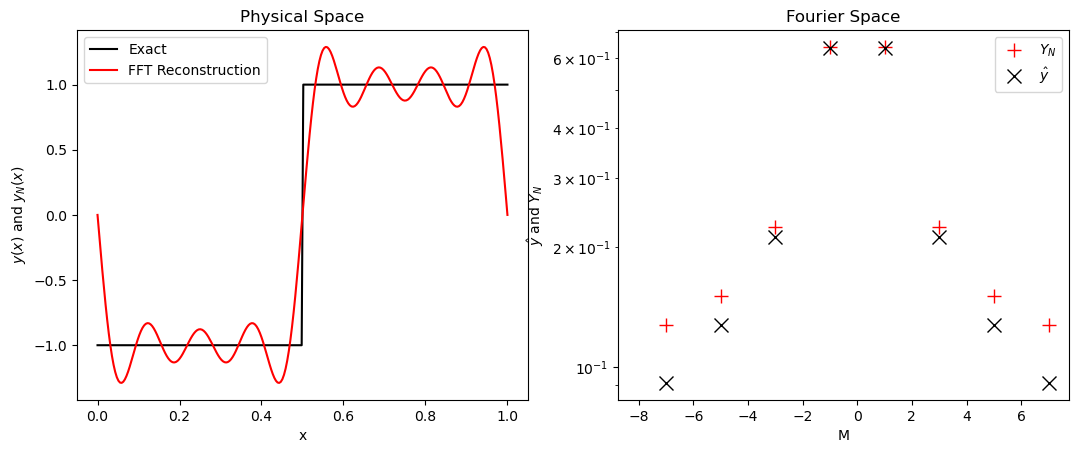

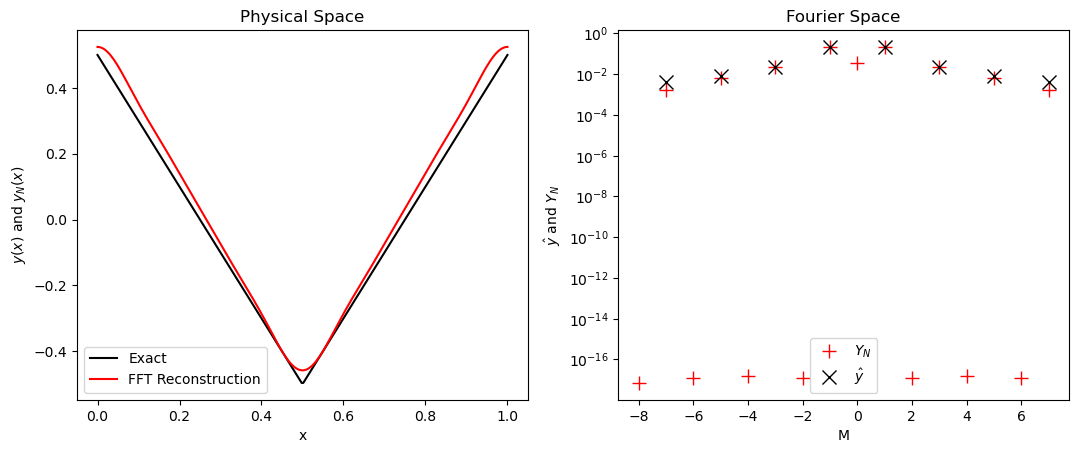

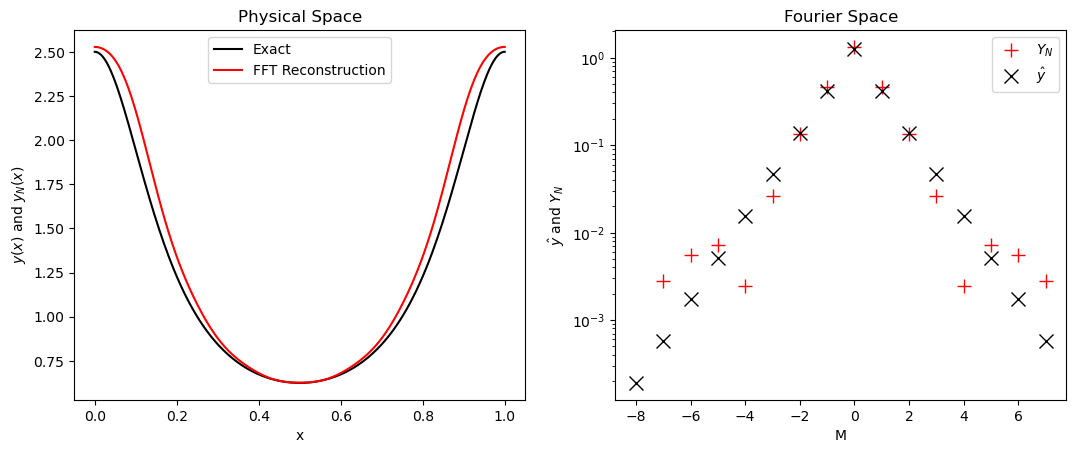

In [2]:
import numpy
from numpy import fft
import matplotlib.pyplot as plt

L = 1.0
N = 2**4
x = numpy.linspace(0.0, L, N)
delta_x = L / N
x_fine = numpy.linspace(0.0, L, 2**8)
M = fft.fftfreq(N, 1.0 / N)

# Hanya ambil M ganjil dan bukan nol
M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]
k = 2.0 * numpy.pi * M / L

funcs = [
    lambda x: numpy.sign(x - 0.5),
    lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,
    lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))
]

# Tambahkan pengecekan M != 0 untuk hindari division by zero
funcs_hat = [
    lambda M: numpy.where(M != 0, -2.0j / (numpy.pi * M), 0),
    lambda M: numpy.where(M != 0, 2.0 / (numpy.pi * M)**2, 0),
    lambda M: 1.25 * 3.0**(-numpy.abs(M))
]

for i, func in enumerate(funcs):
    Y = fft.fft(func(x))
    y_inv = numpy.zeros(x_fine.shape[0])
    for m in range(N):
        y_inv += ((Y[m] / N) * numpy.exp(1.0j * k[m] * (x_fine - 1.0 / (2.0 * N)))).real

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.plot(x_fine, func(x_fine), 'k', label='Exact')
    axes.plot(x_fine, y_inv, 'r', label='FFT Reconstruction')
    axes.set_xlabel("x")
    axes.set_ylabel("$y(x)$ and $y_N(x)$")
    axes.set_title("Physical Space")
    axes.legend()

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(M, numpy.abs(Y) / N, '+r', markersize=10, label='$Y_N$')
    if i != 2:
        axes.semilogy(M_odd, numpy.abs(funcs_hat[i](M_odd)), 'xk', markersize=10, label='$\\hat{y}$')
    else:
        axes.semilogy(M, numpy.abs(funcs_hat[i](M)), 'xk', markersize=10, label='$\\hat{y}$')
    axes.set_xlabel("M")
    axes.set_ylabel("$\\hat{y}$ and $Y_N$")
    axes.set_title("Fourier Space")
    axes.legend()

plt.show()

Secara praktis, kita bisa mengatakan bahwa semakin halus (*smooth*) suatu fungsi, semakin sedikit koefisien Fourier yang kita butuhkan untuk dapat mengaproksimasi fungsi $y(x)$.


### Sifat-Sifat DFT

Bayangkan kamu punya sekumpulan data nilai fungsi di beberapa titik, misalnya $N = 16$ titik. Data ini disimpan dalam vektor $\mathbf{y}$.

DFT adalah cara untuk "mengubah" data tersebut dari domain fisik (nilai fungsi di titik-titik $x$) ke domain frekuensi (seberapa besar kontribusi tiap gelombang/frekuensi). Proses ini bisa ditulis sebagai perkalian matriks:
$$
    \mathbf{Y} = DFT(\mathbf{y}) = N^{1/2} \mathbf{F} \mathbf{y}
$$
Artinya $\mathbf{F}$ adalah matriks yang berisi nilai-nilai gelombang kompleks, mengalikan $\mathbf{F}$ dengan $\mathbf{y}$ berarti kita "memproyeksikan" data ke setiap frekuensi, dan $N^{1/2}$ adalah faktor normalisasi agar skalanya benar. Elemen matriks $\mathbf{F}$ didefinisikan sebagai:
$$
    F_{mn} = N^{-1/2} \exp(-2 \pi i (m - 1)(n - 1))
$$

Invers DFT adalah kebalikannya, yaitu mengubah balik dari domain frekuensi ke domain fisik:
$$
    \mathbf{y} = DFT^{-1}(\mathbf{Y}) = N^{1/2} \mathbf{F}^\ast \mathbf{Y}
$$
Di sini $\mathbf{F}^\ast$ (konjugat transpose) bekerja seperti "kebalikan" dari $\mathbf{F}$, sehingga kita bisa mendapatkan kembali data asli $\mathbf{y}$.


### Identitas Parseval dan Teorema Konvolusi

Dari sifat matriks $\mathbf{F}$ yang unitary (artinya $\mathbf{F}^\ast \mathbf{F} = \mathbf{F} \mathbf{F}^\ast = \mathbf{I}$, seperti matriks rotasi yang jika dibalik sama dengan transposenya), kita bisa menurunkan Identitas Parseval untuk transformasi diskrit:

$$\begin{aligned}
    \sum^N_{m=1} \frac{|Y^2_m|}{N} &= \frac{\mathbf{Y}^\ast \mathbf{Y}}{N} \\
    &= \mathbf{y}^\ast \mathbf{F}^\ast \mathbf{F} \mathbf{y} \\
    &= \mathbf{y}^\ast \mathbf{y} \\
    &= \sum^N_{n=1} |y^2_n|
\end{aligned}$$

Identitas ini mengatakan bahwa total energi di domain fisik sama dengan total energi di domain frekuensi. Dengan kata lain, DFT hanya "memindahkan" representasi data, bukan mengubah besar totalnya.

DFT juga memenuhi Teorema Konvolusi, yaitu:
$$
    DFT(w \ast y) = W_m Y_m
$$
di mana konvolusi $w$ dan $y$ didefinisikan sebagai:
$$
    (w \ast y)_n = \sum^N_{p=1} w_p y_{n-p}
$$

Teorema ini sangat berguna karena konvolusi di domain fisik (yang perhitungannya berat) bisa diganti dengan perkalian biasa di domain frekuensi (yang jauh lebih cepat). Ini adalah alasan utama mengapa DFT/FFT sangat populer dalam pemrosesan sinyal dan numerik.

### Teorema: Kehalusan Fungsi dan Peluruhan Koefisien Fourier

Misalkan $u \in L^2(\mathbb{R})$ memiliki transformasi Fourier $\hat{u}$. Teorema ini menghubungkan **seberapa halus fungsi $u$** dengan seberapa cepat koefisien Fouriernya mengecil saat frekuensi $|k| \to \infty$.

1. Fungsi dengan $p$ turunan (kehalusan terbatas)

Jika $u$ memiliki $p-1$ turunan kontinu di $L^2(\mathbb{R})$ dan turunan ke-$p$ nya terbatas variasinya, maka:
$$
    \hat{u}(k) = \mathcal{O}(|k|^{-p-1}) \quad \text{saat} \quad |k| \rightarrow \infty
$$
Artinya: semakin banyak turunan yang dimiliki fungsi, semakin cepat koefisien Fouriernya mengecil. Fungsi yang "kasar" (sedikit turunan) peluruhan koefisiennya lambat, sehingga butuh banyak suku Fourier.

2. Fungsi dengan tak hingga turunan (konvergensi spektral)

Jika $u$ memiliki tak hingga banyak turunan kontinu, maka untuk setiap $m \geq 0$:
$$
    \hat{u}(k) = \mathcal{O}(|k|^{-m}) \quad \text{saat} \quad |k| \rightarrow \infty
$$
Ini berarti koefisien Fourier mengecil lebih cepat dari pangkat apapun, yang disebut konvergensi spektral. Ini adalah tingkat konvergensi terbaik yang bisa dicapai. Berlaku pula sebaliknya (*converse*).

3. Fungsi analitik di strip kompleks (peluruhan eksponensial)

Jika $u$ dapat diperluas menjadi fungsi analitik di strip kompleks $|\Im(z)| < a$ dengan norma $\|u(\cdot + iy)\|$ terbatas secara seragam untuk semua $y \in (-a, a)$, maka:
$$
    u_a(k) = e^{a|k|} \hat{u}(k) \in L^2(\mathbb{R})
$$
Artinya $\hat{u}(k)$ meluruh secara eksponensial seperti $e^{-a|k|}$. Ini bahkan lebih cepat dari konvergensi spektral! Berlaku pula sebaliknya.

4. Fungsi entire dengan pertumbuhan eksponensial (dukungan kompak)

Jika $u$ dapat diperluas menjadi fungsi analitik di seluruh bidang kompleks (*entire function*) dan tumbuh paling cepat seperti $e^{a|z|}$, maka $\hat{u}$ memiliki dukungan kompak (*compact support*) yang termuat dalam $[-a, a]$. Artinya koefisien Fourier $\hat{u}(k) = 0$ untuk $|k| > a$. Berlaku pula sebaliknya.

### Diferensiasi

Ingat kembali bahwa transformasi Fourier dari suatu turunan mengubah operasi diferensial menjadi operasi aljabar biasa:
$$
    \widehat{(u_x)} = i \xi \hat{u~}
$$

Artinya menurunkan fungsi di domain fisik sama saja dengan mengalikan koefisien Fouriernya dengan $i\xi$ di domain frekuensi. Ini sangat menguntungkan karena perkalian jauh lebih mudah dihitung daripada diferensiasi.
Sifat ini juga bisa kita manfaatkan dalam kasus diskrit, sehingga turunan numerik bisa dihitung secara efisien menggunakan DFT/FFT.

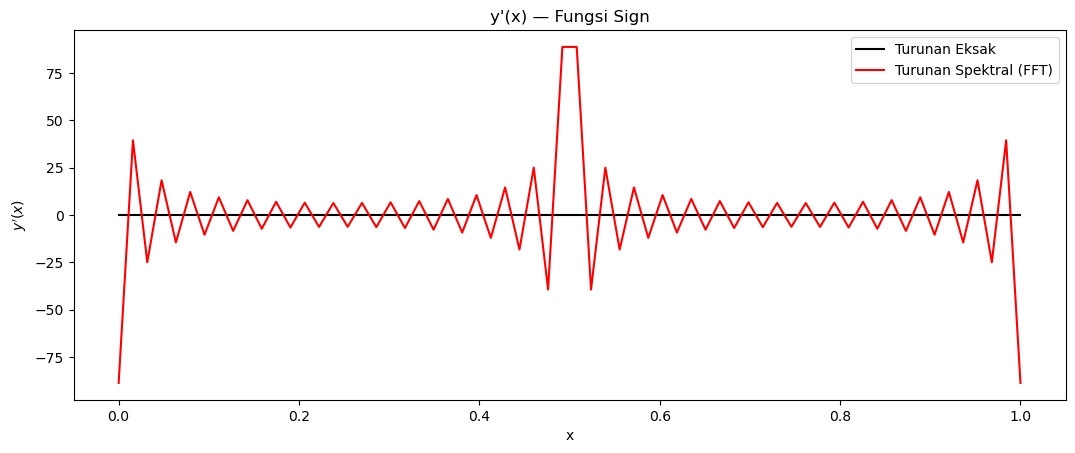

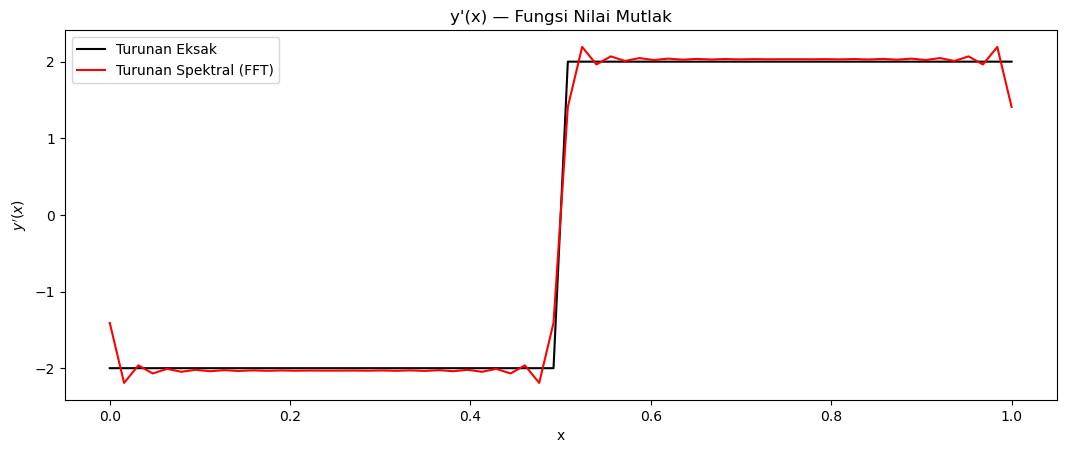

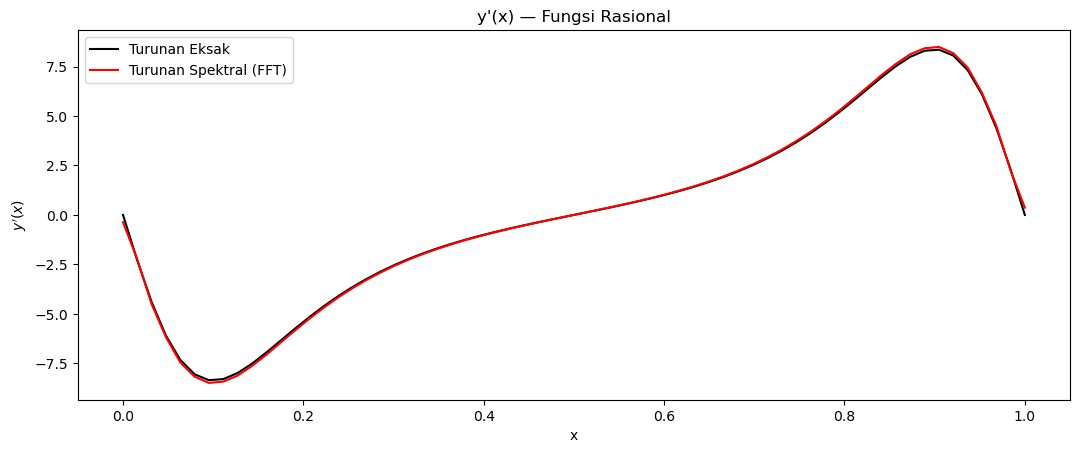

In [3]:
import numpy
from numpy import fft
import matplotlib.pyplot as plt

L = 1.0
N = 2**6
x = numpy.linspace(0.0, L, N)
M = fft.fftfreq(N, 1.0 / N)
k = 2.0 * numpy.pi * M / L

y_funcs = [
    lambda x: numpy.sign(x - 0.5),
    lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,
    lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))
]

y_prime_funcs = [
    lambda x: numpy.zeros(x.shape[0]),  # turunan sign (approx)
    lambda x: 2.0 * numpy.sign(x - 0.5),  # turunan |2x-1| - 0.5
    lambda x: -1.2 * numpy.pi / L * numpy.sin(2.0 * numpy.pi / L * x) 
              / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))**2
]

titles = [
    "y'(x) — Fungsi Sign",
    "y'(x) — Fungsi Nilai Mutlak",
    "y'(x) — Fungsi Rasional"
]

for i, y in enumerate(y_funcs):
    Y = fft.fft(y(x))
    y_prime = fft.ifft(1.0j * k * Y).real  # turunan spektral

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, y_prime_funcs[i](x), 'k', label="Turunan Eksak")
    axes.plot(x, y_prime, 'r', label="Turunan Spektral (FFT)")
    axes.set_xlabel("x")
    axes.set_ylabel("$y'(x)$")
    axes.set_title(titles[i])
    axes.legend()

plt.show()

Kita juga bisa menulis operasi ini sebagai **operasi matriks** (dengan asumsi fungsi periodik):
$$\begin{aligned}
    y'(x) \approx N^{-1/2} \mathbf{F}^\ast i \mathbf{K} \mathbf{Y} = N^{-1/2} \mathbf{F}^\ast i \mathbf{K} N^{1/2} \mathbf{F} \mathbf{y} = \mathbf{D} \mathbf{y}
\end{aligned}$$
di mana $\mathbf{D} \equiv \mathbf{F}^\ast (i \mathbf{K}) \mathbf{F}$ adalah *matriks diferensiasi pseudospektral Fourier*. Matriks ini bersifat real, dense, anti-simetris, dan berukuran $N \times N$. Sedangkan $\mathbf{K} \equiv \text{diag}(\mathbf{k})$.

Selain itu, karena $\mathbf{F}$ adalah matriks unitary, kita bisa menyusun beberapa turunan sekaligus dengan cukup menerapkan matriks tersebut beberapa kali untuk mendapatkan turunan ke-$p$:
$$
    D^p = (\mathbf{F}^\ast i \mathbf{K} \mathbf{F})^p = \mathbf{F}^\ast (i \mathbf{K})^p \mathbf{F}
$$

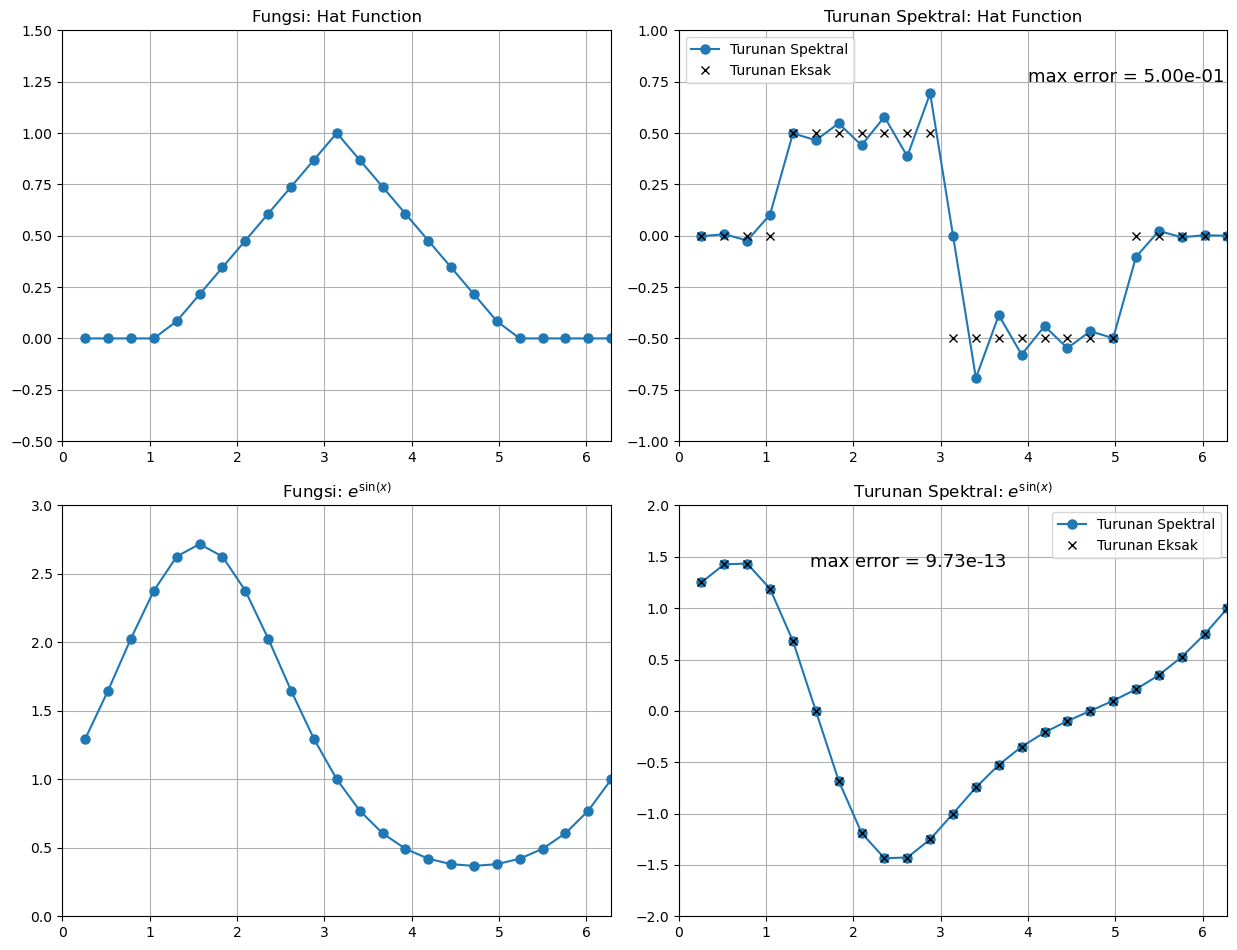

In [4]:
import numpy
import matplotlib.pyplot as plt
import scipy.linalg as linalg

N = 24
delta_x = 2.0 * numpy.pi / N
x = numpy.linspace(delta_x, delta_x * N, N)

# Bangun matriks diferensiasi Toeplitz
column = numpy.empty(N)
column[1:] = 0.5 * (-1.0)**(numpy.arange(1, N)) / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)
column[0] = 0.0
index_array = numpy.empty(N, dtype=int)
index_array[0] = 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))
D = linalg.toeplitz(column, column[index_array])

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)

# --- Fungsi 1: Hat function ---
v = numpy.where(1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0,
                1 - numpy.abs(x - numpy.pi) / 2.0, 0.0)
v_prime = (numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0)
           * (x < numpy.pi) * 0.5
           - numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0)
           * (x > numpy.pi) * 0.5)

axes[0, 0].plot(x, v, '.-', markersize=13)
axes[0, 0].set_xlim((0, 2 * numpy.pi))
axes[0, 0].set_ylim((-0.5, 1.5))
axes[0, 0].set_title("Fungsi: Hat Function")
axes[0, 0].grid(True)

axes[0, 1].plot(x, numpy.dot(D, v), '.-', markersize=13, label="Turunan Spektral")
axes[0, 1].plot(x, v_prime, 'kx', label="Turunan Eksak")
axes[0, 1].set_xlim((0, 2 * numpy.pi))
axes[0, 1].set_ylim((-1, 1))
axes[0, 1].set_title("Turunan Spektral: Hat Function")
axes[0, 1].grid(True)
axes[0, 1].legend()
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)
axes[0, 1].text(4.0, 0.75, "max error = %.2e" % error, fontsize=13)

# --- Fungsi 2: exp(sin(x)) ---
v = numpy.exp(numpy.sin(x))
v_prime = numpy.cos(x) * v

axes[1, 0].plot(x, v, '.-', markersize=13)
axes[1, 0].set_xlim((0, 2 * numpy.pi))
axes[1, 0].set_ylim((0.0, 3.0))
axes[1, 0].set_title("Fungsi: $e^{\\sin(x)}$")
axes[1, 0].grid(True)

axes[1, 1].plot(x, numpy.dot(D, v), '.-', markersize=13, label="Turunan Spektral")
axes[1, 1].plot(x, v_prime, 'kx', label="Turunan Eksak")
axes[1, 1].set_xlim((0, 2 * numpy.pi))
axes[1, 1].set_ylim((-2, 2))
axes[1, 1].set_title("Turunan Spektral: $e^{\\sin(x)}$")
axes[1, 1].grid(True)
axes[1, 1].legend()
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)
axes[1, 1].text(1.5, 1.4, "max error = %.2e" % error, fontsize=13)

plt.tight_layout()
plt.show()

### Metode Spektral

Kita juga bisa menerapkan pendekatan di atas jika kondisi batas periodik digunakan dan solusi yang diharapkan halus (smooth). Mari kita pelajari melalui sebuah contoh.

Kita ingin menyelesaikan persamaan adveksi dengan kecepatan yang bervariasi:
$$
    u_t + c(x) u_x = 0, \quad \Omega = [0, 2\pi]
$$
dengan kondisi batas periodik, kondisi awal:
$$
    u(x,0) = \exp(-100(x-1)^2)
$$
dan kecepatan yang bervariasi:
$$
    c(x) = 1/5 + \sin^2(x-1)
$$

Sekarang mari kita bangun sebuah metode berdasarkan leapfrog dan pendekatan diferensiasi di atas. Perhatikan bahwa dalam perspektif method of lines, kita memiliki:
$$
    \frac{U^{n+1}_j - U^{n-1}_j}{2 \Delta t} = f(U^n) = -c(x_j) (D U^n)_j
$$
di mana kita menggunakan matriks diferensiasi di atas sebagai pengganti beda hingga terpusat (*centered difference*). Kita juga bisa menggunakan metode yang lebih efisien berdasarkan transformasi Fourier dari turunan. Perlu dicatat bahwa kita menggunakan pendekatan aproksimasi di sini untuk mem-*bootstrap* metode ini.

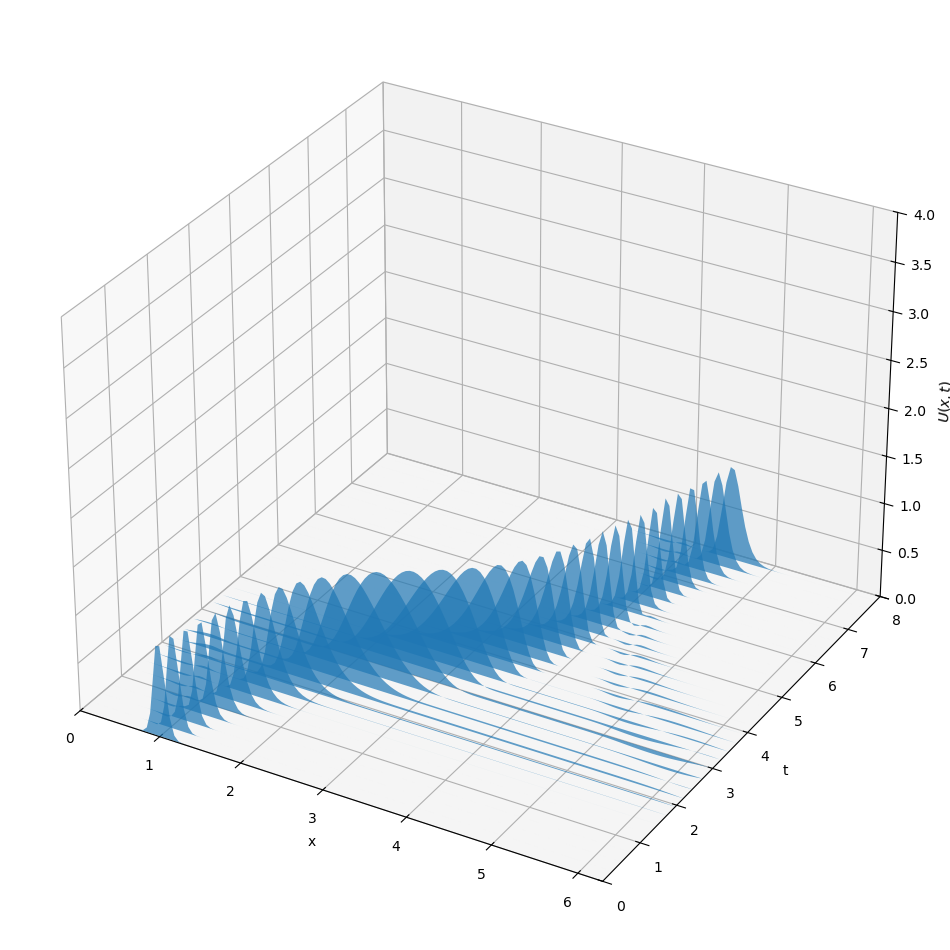

In [5]:
import numpy                                                                                    # import library numpy
from numpy import fft                                                                          # import modul fft dari numpy
import matplotlib.pyplot as plt                                                                # import matplotlib untuk plotting
import scipy.linalg as linalg                                                                  # import scipy.linalg untuk matriks Toeplitz
from mpl_toolkits.mplot3d import Axes3D                                                        # import toolkit untuk plot 3D
import matplotlib.collections                                                                  # import untuk koleksi objek grafis
import matplotlib.colors                                                                       # import untuk konversi warna

N = 128                                                                                        # jumlah titik grid
L = 2.0 * numpy.pi                                                                            # panjang domain [0, 2*pi]
delta_x = L / N                                                                               # jarak antar titik grid
delta_t = delta_x / 4.0                                                                       # ukuran langkah waktu (CFL condition)
x = numpy.linspace(delta_x, delta_x * N, N)                                                   # array titik grid spasial
M = fft.fftfreq(N, 1.0 / N)                                                                   # frekuensi DFT
k = 2.0 * numpy.pi * M / L                                                                    # bilangan gelombang
c = 0.2 + numpy.sin(x - 1.0)**2                                                               # kecepatan adveksi yang bervariasi c(x) = 1/5 + sin^2(x-1)

column = numpy.empty(N)                                                                        # buat array kosong untuk kolom matriks Toeplitz
column[1:] = 0.5 * (-1.0)**(numpy.arange(1, N)) / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)  # isi kolom dengan rumus diferensiasi spektral
column[0] = 0.0                                                                               # elemen diagonal utama = 0 (anti-simetris)
index_array = numpy.empty(N, dtype=int)                                                        # buat array indeks kosong bertipe integer
index_array[0] = 0                                                                             # indeks pertama tetap 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))                                            # balik urutan indeks 1 sampai N-1
D = linalg.toeplitz(column, column[index_array])                                               # bangun matriks diferensiasi Toeplitz

U = numpy.exp(-100.0 * (x - 1.0)**2)                                                          # kondisi awal u(x,0) = exp(-100*(x-1)^2)
U_old = numpy.exp(-100.0 * (x - 0.2 * delta_t - 1.0)**2)                                     # kondisi awal satu langkah sebelumnya untuk leapfrog
t_final = 8.0                                                                                 # waktu akhir simulasi
num_steps = int(numpy.ceil(t_final / delta_t))                                                 # jumlah langkah waktu total
plot_interval = 20                                                                             # interval langkah untuk menyimpan data plot
t = 0.0                                                                                       # waktu awal
verts = []                                                                                    # list untuk menyimpan data kurva tiap waktu
t_output = []                                                                                 # list untuk menyimpan nilai waktu output

for n in range(num_steps):                                                                     # loop utama untuk setiap langkah waktu
    U_hat = fft.fft(U)                                                                        # hitung DFT dari U
    U_prime_hat = 1.0j * k * U_hat                                                            # kalikan dengan ik untuk turunan di domain frekuensi
    U_prime = fft.ifft(U_prime_hat).real                                                       # transformasi balik ke domain fisik (ambil bagian real)
    U_new = U_old - 2.0 * delta_t * c * U_prime                                               # skema leapfrog: U^{n+1} = U^{n-1} - 2*dt*c*dU/dx
    U_old = U                                                                                 # simpan U saat ini sebagai U lama untuk langkah berikutnya
    U = U_new                                                                                 # perbarui U dengan nilai baru
    t += delta_t                                                                              # tambah waktu sebesar delta_t
    if numpy.mod(n, plot_interval) == 0:                                                       # cek apakah saatnya menyimpan data plot
        t_output.append(t)                                                                    # simpan nilai waktu saat ini
        verts.append(list(zip(x, U)))                                                         # simpan pasangan (x, U) untuk plot 3D

poly = matplotlib.collections.PolyCollection(verts)                                           # buat koleksi poligon dari data kurva
poly.set_alpha(0.7)                                                                           # atur transparansi poligon

fig = plt.figure()                                                                            # buat figure baru
fig.set_figwidth(fig.get_figwidth() * 2)                                                       # perlebar ukuran figure
fig.set_figheight(fig.get_figheight() * 2)                                                     # pertinggi ukuran figure
axes = fig.add_subplot(1, 1, 1, projection='3d')                                              # buat subplot dengan proyeksi 3D
axes.add_collection3d(poly, zs=t_output, zdir='y')                                            # tambahkan koleksi poligon ke plot 3D
axes.set_xlabel("x")                                                                          # label sumbu x
axes.set_xlim3d(0.0, 2.0 * numpy.pi)                                                          # batas sumbu x dari 0 sampai 2*pi
axes.set_ylabel("t")                                                                          # label sumbu y (waktu)
axes.set_ylim3d(0.0, 8.0)                                                                     # batas sumbu y (waktu) dari 0 sampai 8
axes.set_zlabel("$U(x,t)$")                                                                   # label sumbu z dengan notasi LaTeX
axes.set_zlim(0.0, 4.0)                                                                       # batas sumbu z dari 0 sampai 4

plt.tight_layout()                                                                            # atur layout agar tidak bertumpuk
plt.show()                                                                                    # tampilkan plot

## Solver Poisson Berbasis FFT

Pada kuliah sebelumnya tentang metode iteratif untuk masalah Poisson, sempat disebutkan bahwa ada cara untuk menyelesaikan masalah Poisson menggunakan FFT. Di sini kita akan mengeksplorasi beberapa ide di balik metode-metode yang sangat powerful ini.

Pertama, perhatikan masalah Poisson satu dimensi yang didefinisikan sebagai:
$$
    u_{xx} = f(x), \quad \Omega = [0, L]
$$
di mana $f(x)$ bersifat periodik beserta kondisi batasnya yang juga periodik.

Perhatikan solusi yang merupakan kombinasi linear dari basis Fourier hingga:
$$
    u(x) \approx \frac{1}{N} \sum^N_{n=1} U_n \exp(i k_n x)
$$
di mana bilangan gelombang $k_n$ didefinisikan sebagai:
$$
    k_n = \frac{2 \pi}{L} \left\{ \begin{aligned} 
        n - 1, & & 1 \leq n \leq N/2 \\
        n - N - 1, & & N/2 + 1 \leq n \leq N.
    \end{aligned} \right .
$$
Artinya, untuk separuh pertama indeks ($1 \leq n \leq N/2$) kita menggunakan **frekuensi positif**, sedangkan untuk separuh kedua ($N/2 + 1 \leq n \leq N$) kita menggunakan frekuensi negatif. Ini sesuai dengan konvensi standar yang digunakan oleh fungsi `fftfreq` pada NumPy.

Sekarang perhatikan $N$ titik kolokasi Fourier:
$$
    x_j = \frac{(j-1) L}{N}, \quad j = 1, \ldots, N
$$
dan vektor-vektor yang bersesuaian $\mathbf{u} = [u(x_j)]_j$ dan $\mathbf{f} = [f(x_j)]_j$. Dengan mengambil transformasi Fourier dari kedua sisi PDE asal, kita mendapatkan:
$$\begin{aligned}
    (-i k_n)^2 \hat{u~}(k) &= \hat{f}(k) \\
    \hat{u~}(k) &= -\frac{\hat{f~}(k)}{k_n^2}.
\end{aligned}$$
Mengambil transformasi balik dari kedua sisi akan menghasilkan solusinya. Dalam kasus diskrit, kita memiliki:
$$
    \hat{\mathbf{f}~} = \text{DFT}(\mathbf{f}) \\
    U_n = -\frac{\hat{\mathbf{f}~}}{k_n^2} \\
    \mathbf{u} = \text{IDFT}\left(-\frac{\hat{\mathbf{f}~}}{k_n^2}\right)
$$
Artinya, kita cukup mentransformasi $\mathbf{f}$ ke domain frekuensi, membagi setiap koefisien dengan $k_n^2$, lalu mentransformasi balik hasilnya untuk mendapatkan solusi $\mathbf{u}$. Perhatikan bahwa saat $k_n = 0$ (mode konstan), pembagian tidak terdefinisi — ini mencerminkan fakta bahwa solusi Poisson dengan kondisi batas periodik hanya unik sampai sebuah konstanta.

Salah satu masalah yang akan kita hadapi adalah $k_n = 0$ untuk $n=1$. Kita bisa mengasumsikan bahwa $F_1 = 0$ sehingga kita setidaknya bisa menangani komponen ini secara unik (secara teknis tetap akan ada bentuk $0/0$, namun ada cara untuk menangani kasus ini).

Pertanyaannya adalah apakah kita benar-benar harus mengikuti pendekatan ini. Syarat bahwa $f_1 = 0$ sebenarnya merupakan syarat well-posedness dari masalah Poisson pada domain periodik. Komponen ini merepresentasikan nilai rata-rata dari fungsi $f(x)$, dan untungnya dapat dengan mudah dikurangkan dari fungsi tersebut.

Pada kenyataannya, sistem ini juga tidak tertutup dalam kasus ini — terdapat tak hingga banyak solusi yang berbeda sebesar nilai rata-ratanya (solusi hanya ditentukan hingga sebuah konstanta tambahan). Di sini kita secara khusus menetapkan bahwa kita mencari solusi di mana konstanta tersebut bernilai nol.

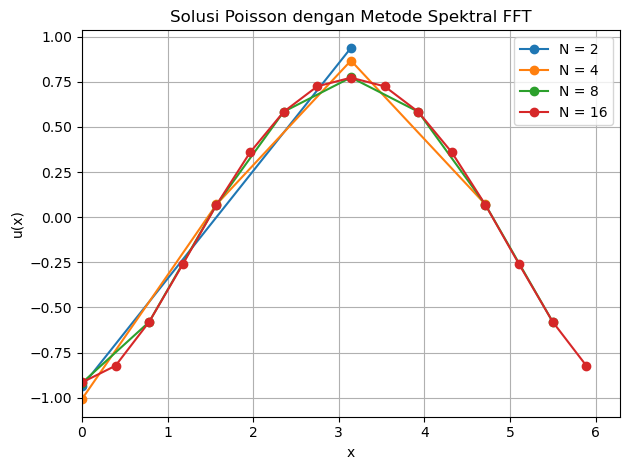

In [6]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
from numpy import fft                                                                          # import modul fft dari numpy untuk transformasi Fourier
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

L = 2.0 * numpy.pi                                                                            # menetapkan panjang domain spasial yaitu 2*pi
f = lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi * x / L))                         # mendefinisikan fungsi sumber f(x) = 1/(1 - 0.6*cos(2*pi*x/L))

fig, axes = plt.subplots(1, 1)                                                                 # membuat figure dengan satu subplot
for N in [2, 4, 8, 16]:                                                                        # melakukan iterasi untuk berbagai jumlah titik grid N
    delta_x = L / N                                                                            # menghitung jarak antar titik grid spasial
    x = numpy.linspace(0.0, delta_x * (N - 1), N)                                             # membuat array N titik grid dari 0 sampai L - delta_x

    M = fft.fftfreq(N, 1.0 / N)                                                               # menghitung frekuensi diskrit untuk transformasi Fourier
    k = 2.0 * numpy.pi * M / L                                                                # menghitung bilangan gelombang dari frekuensi diskrit

    F = fft.fft(f(x))                                                                         # menghitung transformasi Fourier dari f(x)
    if numpy.abs(F[0]) > 1e-10:                                                               # memeriksa apakah komponen rata-rata (mode nol) tidak nol
        F = fft.fft(f(x) - numpy.mean(f(x)))                                                  # jika tidak nol, kurangi nilai rata-rata f(x) agar well-posed

    U_hat = numpy.zeros(N, dtype=complex)                                                      # membuat array koefisien Fourier solusi bertipe kompleks diisi nol
    U_hat[0] = 0.0                                                                            # menetapkan mode nol (konstanta) sama dengan nol
    U_hat[1:] = -F[1:] / k[1:]**2                                                             # menghitung koefisien Fourier solusi dengan membagi F oleh k^2

    U = fft.ifft(U_hat).real                                                                   # menghitung solusi u(x) dengan transformasi Fourier balik dan ambil bagian real
    U = U - numpy.mean(U)                                                                      # mengurangi nilai rata-rata solusi agar konsisten (unik sampai konstanta)

    axes.plot(x, U, 'o-', label=f'N = {N}')                                                   # memplot solusi u(x) dengan titik dan garis untuk setiap nilai N
    axes.set_xlim(0.0, L)                                                                     # menetapkan batas sumbu x dari 0 sampai L
    axes.set_xlabel("x")                                                                      # memberikan label sumbu x
    axes.set_ylabel("u(x)")                                                                   # memberikan label sumbu y sebagai nilai solusi
    axes.set_title("Solusi Poisson dengan Metode Spektral FFT")                               # memberikan judul plot
    axes.legend()                                                                             # menampilkan legenda untuk membedakan setiap nilai N
    axes.grid(True)                                                                           # menampilkan grid pada plot

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

#### Metode Spektral Chebyshev

Lalu apa yang terjadi jika domain kita tidak periodik? Kita bisa berpikir untuk menggunakan polinomial biasa sebagai pengganti polinomial trigonometri (basis Fourier kita). Namun dari teori interpolasi, kita tahu bahwa menggunakan titik-titik yang berjarak sama adalah ide yang buruk karena akan menyebabkan osilasi liar di dekat batas domain (fenomena Runge).

Sebagai gantinya, kita akan mendistribusikan titik-titik interpolasi sedemikian sehingga:
$$
    x_j = \cos\left(\frac{j \pi}{N} \right), \quad j=0, 1, \ldots, N
$$
yang disebut titik-titik Chebyshev jenis kedua. Titik-titik ini lebih rapat di dekat ujung domain ($x = \pm 1$) dan lebih jarang di tengah, sehingga dapat menghindari osilasi yang tidak diinginkan dan menghasilkan aproksimasi yang jauh lebih akurat.

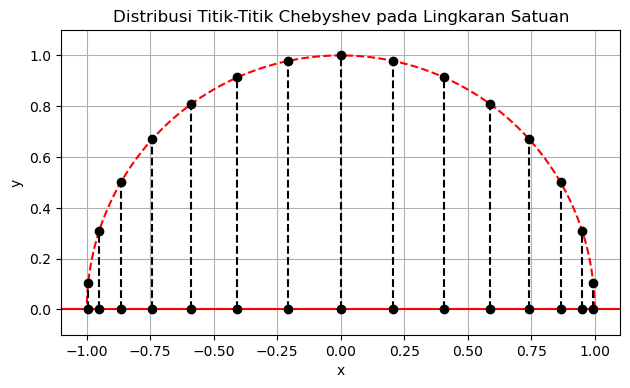

In [7]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

x = numpy.linspace(0, numpy.pi, 100)                                                          # membuat array sudut dari 0 sampai pi untuk menggambar setengah lingkaran
N = 15                                                                                        # menetapkan jumlah titik Chebyshev yang akan ditampilkan

fig = plt.figure()                                                                            # membuat objek figure baru
axes = fig.add_subplot(1, 1, 1)                                                               # menambahkan satu subplot ke dalam figure

axes.plot(numpy.cos(x), numpy.sin(x), 'r--')                                                  # menggambar setengah lingkaran satuan berwarna merah putus-putus
axes.plot(numpy.linspace(-1.1, 1.1, 100), numpy.zeros(100), 'r')                              # menggambar garis horizontal sumbu x berwarna merah

for k in range(1, N + 1):                                                                     # melakukan iterasi untuk setiap titik Chebyshev jenis pertama ke-k
    location = [numpy.cos((2.0 * k - 1.0) * numpy.pi / (2.0 * N)),                           # menghitung koordinat x titik Chebyshev pada lingkaran satuan
                numpy.sin((2.0 * k - 1.0) * numpy.pi / (2.0 * N))]                           # menghitung koordinat y titik Chebyshev pada lingkaran satuan
    axes.plot(location[0], location[1], 'ko')                                                 # memplot titik Chebyshev pada lingkaran satuan dengan titik hitam
    axes.plot(location[0], 0.0, 'ko')                                                         # memplot proyeksi titik Chebyshev ke sumbu x dengan titik hitam
    axes.plot([location[0], location[0]], [0.0, location[1]], 'k--')                          # menggambar garis putus-putus vertikal dari sumbu x ke titik pada lingkaran

axes.set_xlim((-1.1, 1.1))                                                                    # menetapkan batas sumbu x dari -1.1 sampai 1.1
axes.set_ylim((-0.1, 1.1))                                                                    # menetapkan batas sumbu y dari -0.1 sampai 1.1
axes.set_xlabel("x")                                                                          # memberikan label sumbu x
axes.set_ylabel("y")                                                                          # memberikan label sumbu y
axes.set_title("Distribusi Titik-Titik Chebyshev pada Lingkaran Satuan")                      # memberikan judul plot
axes.set_aspect('equal')                                                                      # memastikan skala sumbu x dan y sama agar lingkaran tidak terdistorsi
axes.grid(True)                                                                               # menampilkan grid pada plot

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan plot yang telah dibuat

Dengan menggunakan basis Lagrange , kita dapat langsung melihat bagaimana perbandingan antara penggunaan titik-titik berjarak sama(*equispaced points*) dengan titik-titik Chebyshev. Titik-titik berjarak sama cenderung menghasilkan osilasi besar di dekat ujung domain (dikenal sebagai fenomena Runge), sedangkan titik-titik Chebyshev yang lebih rapat di dekat batas dapat menekan osilasi tersebut dan menghasilkan interpolasi yang jauh lebih akurat.

True


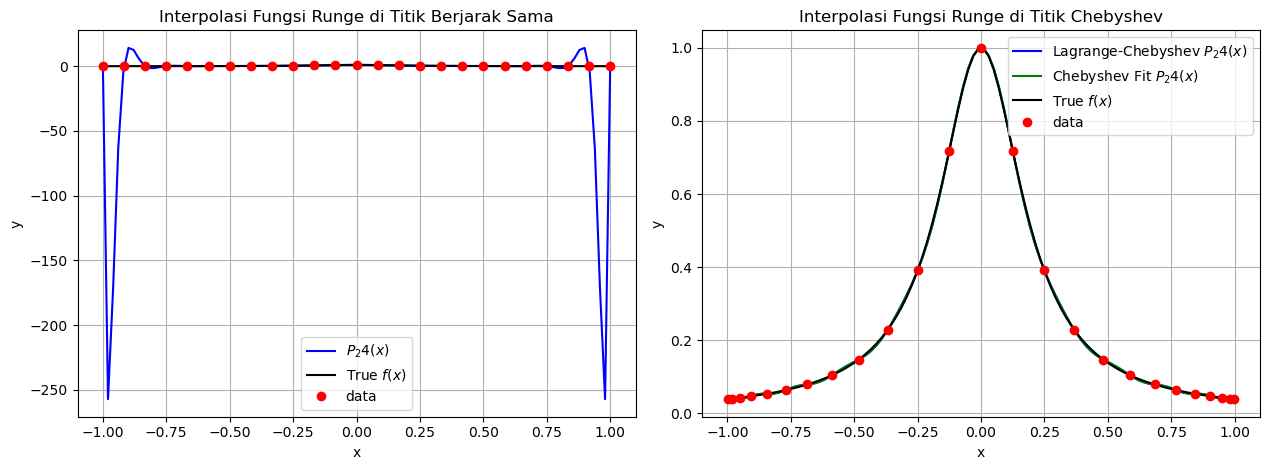

In [8]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

def f(x):                                                                                     # mendefinisikan fungsi Runge yang terkenal sulit diinterpolasi
    return 1.0 / (1.0 + 25.0 * x**2)                                                         # rumus fungsi Runge f(x) = 1/(1 + 25x^2)

x = numpy.linspace(-1, 1, 100)                                                                # membuat array titik evaluasi halus dari -1 sampai 1 untuk plot
num_points = 25                                                                               # menetapkan jumlah titik interpolasi yang akan digunakan

# ============================================================
# Titik-titik berjarak sama (Equispaced)
equidistant_data = numpy.empty((num_points, 2))                                               # membuat array kosong untuk menyimpan koordinat titik berjarak sama
equidistant_data[:, 0] = numpy.linspace(-1, 1, num_points)                                    # mengisi kolom pertama dengan titik-titik berjarak sama dari -1 sampai 1
equidistant_data[:, 1] = f(equidistant_data[:, 0])                                            # mengisi kolom kedua dengan nilai fungsi Runge di setiap titik
N = equidistant_data.shape[0] - 1                                                             # menetapkan derajat polinomial interpolasi yaitu jumlah titik dikurangi satu

lagrange_basis = numpy.ones((N + 1, x.shape[0]))                                              # membuat array basis Lagrange diinisialisasi dengan satu
for i in range(N + 1):                                                                        # melakukan iterasi untuk setiap basis Lagrange ke-i
    for j in range(N + 1):                                                                    # melakukan iterasi untuk setiap faktor dalam produk basis Lagrange
        if i != j:                                                                            # melewati suku ketika indeks i sama dengan j agar tidak dibagi nol
            lagrange_basis[i, :] *= (x - equidistant_data[j, 0]) / (equidistant_data[i, 0] - equidistant_data[j, 0])  # mengalikan faktor basis Lagrange ke-i

P_lagrange = numpy.zeros(x.shape[0])                                                          # membuat array nol untuk menyimpan hasil polinomial interpolasi
for n in range(N + 1):                                                                        # melakukan iterasi untuk setiap suku dalam polinomial Lagrange
    P_lagrange += lagrange_basis[n, :] * equidistant_data[n, 1]                               # menambahkan kontribusi setiap basis dikalikan nilai fungsi di titik tersebut

# ============================================================
# Titik-titik Chebyshev
chebyshev_data = numpy.empty((num_points, 2))                                                 # membuat array kosong untuk menyimpan koordinat titik Chebyshev
chebyshev_data[:, 0] = numpy.cos((2.0 * numpy.arange(1, num_points + 1) - 1.0) * numpy.pi / (2.0 * num_points))  # menghitung titik-titik Chebyshev jenis pertama
chebyshev_data[:, 1] = f(chebyshev_data[:, 0])                                                # mengisi kolom kedua dengan nilai fungsi Runge di setiap titik Chebyshev

lagrange_basis = numpy.ones((N + 1, x.shape[0]))                                              # membuat ulang array basis Lagrange diinisialisasi dengan satu
for i in range(N + 1):                                                                        # melakukan iterasi untuk setiap basis Lagrange ke-i menggunakan titik Chebyshev
    for j in range(N + 1):                                                                    # melakukan iterasi untuk setiap faktor dalam produk basis Lagrange
        if i != j:                                                                            # melewati suku ketika indeks i sama dengan j agar tidak dibagi nol
            lagrange_basis[i, :] *= (x - chebyshev_data[j, 0]) / (chebyshev_data[i, 0] - chebyshev_data[j, 0])  # mengalikan faktor basis Lagrange ke-i dengan titik Chebyshev

P_cheby1 = numpy.zeros(x.shape[0])                                                            # membuat array nol untuk menyimpan hasil interpolasi Lagrange di titik Chebyshev
for n in range(N + 1):                                                                        # melakukan iterasi untuk setiap suku dalam polinomial Lagrange Chebyshev
    P_cheby1 += lagrange_basis[n, :] * chebyshev_data[n, 1]                                   # menambahkan kontribusi setiap basis dikalikan nilai fungsi di titik Chebyshev

coeff = numpy.polynomial.chebyshev.chebfit(chebyshev_data[:, 0], chebyshev_data[:, 1], N)    # menghitung koefisien polinomial Chebyshev secara langsung dengan least squares
P_cheby2 = numpy.polynomial.chebyshev.chebval(x, coeff)                                       # mengevaluasi polinomial Chebyshev di semua titik x menggunakan koefisien tersebut

print(numpy.allclose(P_cheby1, P_cheby2))                                                     # memeriksa apakah kedua pendekatan Chebyshev menghasilkan polinomial yang sama

# ============================================================
# Membuat plot perbandingan
fig = plt.figure()                                                                            # membuat objek figure baru
fig.set_figwidth(fig.get_figwidth() * 2.0)                                                     # memperlebar figure menjadi dua kali ukuran default

axes = fig.add_subplot(1, 2, 1)                                                               # menambahkan subplot pertama di sebelah kiri
axes.plot(x, P_lagrange, 'b', label="$P_%s(x)$" % N)                                         # memplot hasil interpolasi Lagrange di titik berjarak sama dengan warna biru
axes.plot(x, f(x), 'k', label="True $f(x)$")                                                 # memplot fungsi Runge asli dengan warna hitam sebagai pembanding
axes.plot(equidistant_data[:, 0], equidistant_data[:, 1], 'ro', label="data")                 # memplot titik-titik data berjarak sama dengan lingkaran merah
axes.set_title("Interpolasi Fungsi Runge di Titik Berjarak Sama")                             # memberikan judul subplot pertama
axes.set_xlabel("x")                                                                          # memberikan label sumbu x
axes.set_ylabel("y")                                                                          # memberikan label sumbu y
axes.legend(loc=8)                                                                            # menampilkan legenda di bagian bawah tengah subplot
axes.grid(True)                                                                               # menampilkan grid pada subplot pertama

axes = fig.add_subplot(1, 2, 2)                                                               # menambahkan subplot kedua di sebelah kanan
axes.plot(x, P_cheby1, 'b', label="Lagrange-Chebyshev $P_%s(x)$" % N)                        # memplot hasil interpolasi Lagrange di titik Chebyshev dengan warna biru
axes.plot(x, P_cheby2, 'g', label="Chebyshev Fit $P_%s(x)$" % N)                             # memplot hasil fit polinomial Chebyshev langsung dengan warna hijau
axes.plot(x, f(x), 'k', label="True $f(x)$")                                                 # memplot fungsi Runge asli dengan warna hitam sebagai pembanding
axes.plot(chebyshev_data[:, 0], chebyshev_data[:, 1], 'ro', label="data")                     # memplot titik-titik Chebyshev dengan lingkaran merah
axes.set_title("Interpolasi Fungsi Runge di Titik Chebyshev")                                 # memberikan judul subplot kedua
axes.set_xlabel("x")                                                                          # memberikan label sumbu x
axes.set_ylabel("y")                                                                          # memberikan label sumbu y
axes.legend(loc=1)                                                                            # menampilkan legenda di pojok kanan atas subplot
axes.grid(True)                                                                               # menampilkan grid pada subplot kedua

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

Terdapat dua jenis titik Chebyshev yang keduanya bekerja sama baiknya sebagai titik interpolasi.

1. Titik Chebyshev jenis pertama (akar/*roots*)
$$
    x_k = \cos \left (\frac{(2 k - 1) \pi}{2 N} \right ) \quad k = 1, \ldots, N
$$
Titik-titik ini merupakan akar dari polinomial Chebyshev $T_N(x)$, yaitu titik-titik di mana $T_N(x) = 0$.

2. Titik Chebyshev jenis kedua (ekstrem/*extrema*)
$$
    x_k = \cos \left( \frac{k \pi}{N} \right) \quad k = 0, \ldots, N
$$
Titik-titik ini merupakan titik ekstrem dari polinomial Chebyshev $T_N(x)$, yaitu titik-titik di mana $|T_N(x)|$ mencapai nilai maksimumnya. Jenis kedua ini juga mencakup titik ujung domain $x = \pm 1$, sehingga lebih sering digunakan dalam metode spektral untuk masalah dengan kondisi batas.

[ 1.          0.80901699  0.30901699 -0.30901699 -0.80901699 -1.        ]
[0.54030231 0.69021008 0.95263298 0.95263298 0.69021008 0.54030231]


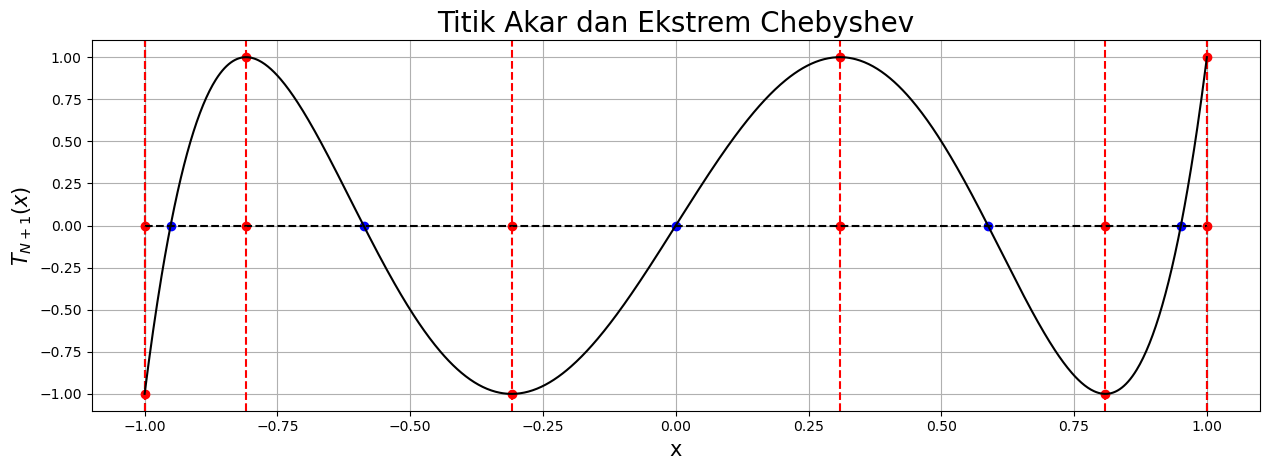

In [9]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

def cheb_poly(x, N):                                                                          # mendefinisikan fungsi untuk menghitung polinomial Chebyshev ke-N
    """Compute the *N*th Chebyshev polynomial and evaluate it at *x*"""                       # docstring: menghitung polinomial Chebyshev ke-N dan mengevaluasinya di x
    T = numpy.empty((3, x.shape[0]))                                                          # membuat array kosong berukuran 3 x len(x) untuk menyimpan tiga baris rekursi
    T[0, :] = numpy.ones(x.shape)                                                             # menginisialisasi T_0(x) = 1 sebagai baris pertama rekursi
    T[1, :] = x                                                                               # menginisialisasi T_1(x) = x sebagai baris kedua rekursi
    for k in range(2, N):                                                                     # melakukan iterasi rekursi dari k=2 sampai k=N-1
        T[2, :] = 2.0 * x * T[1, :] - T[0, :]                                               # menghitung T_k(x) = 2x*T_{k-1}(x) - T_{k-2}(x) menggunakan rumus rekursi Chebyshev
        T[0, :] = T[1, :]                                                                    # menggeser baris: T_{k-2} diganti dengan T_{k-1}
        T[1, :] = T[2, :]                                                                    # menggeser baris: T_{k-1} diganti dengan T_k yang baru dihitung
    return T[2, :]                                                                            # mengembalikan baris terakhir yang berisi nilai polinomial Chebyshev ke-N

N = 5                                                                                         # menetapkan derajat polinomial Chebyshev yang akan diplot
x_extrema = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)                                    # menghitung titik-titik Chebyshev jenis kedua (ekstrem) sebanyak N+1 titik
x_nodes = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)            # menghitung titik-titik Chebyshev jenis pertama (akar) sebanyak N titik

fig = plt.figure()                                                                            # membuat objek figure baru
fig.set_figwidth(fig.get_figwidth() * 2)                                                      # memperlebar figure menjadi dua kali ukuran default
axes = fig.add_subplot(1, 1, 1)                                                               # menambahkan satu subplot ke dalam figure

axes.plot(x_extrema, numpy.zeros(N + 1), 'ro')                                               # memplot titik-titik ekstrem Chebyshev pada sumbu x dengan lingkaran merah
axes.plot(x_nodes, numpy.zeros(N), 'bo')                                                      # memplot titik-titik akar Chebyshev pada sumbu x dengan lingkaran biru

axes.plot((-1.0, -1.0), (-1.1, 1.1), 'k--')                                                  # menggambar garis vertikal putus-putus di batas kiri domain x = -1
axes.plot((1.0, 1.0), (-1.1, 1.1), 'k--')                                                    # menggambar garis vertikal putus-putus di batas kanan domain x = 1
axes.plot((-1.0, 1.0), (0.0, 0.0), 'k--')                                                    # menggambar garis horizontal putus-putus pada sumbu y = 0

for i in range(x_extrema.shape[0]):                                                           # melakukan iterasi untuk setiap titik ekstrem Chebyshev
    axes.plot((x_extrema[i], x_extrema[i]), (-1.1, 1.1), 'r--')                              # menggambar garis vertikal putus-putus merah di setiap titik ekstrem
    axes.plot(x_extrema[i], cheb_poly(x_extrema, N + 1)[i], 'ro')                            # memplot nilai polinomial Chebyshev di setiap titik ekstrem dengan lingkaran merah

print(x_extrema)                                                                              # mencetak nilai koordinat titik-titik ekstrem Chebyshev ke konsol
print(numpy.cos(x_extrema))                                                                   # mencetak nilai kosinus dari titik-titik ekstrem ke konsol

x_hat = numpy.linspace(-1, 1, 1000)                                                           # membuat array titik evaluasi halus sebanyak 1000 titik dari -1 sampai 1
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')                                               # memplot kurva polinomial Chebyshev ke-(N+1) dengan garis hitam

axes.set_xlim((-1.1, 1.1))                                                                    # menetapkan batas sumbu x dari -1.1 sampai 1.1
axes.set_ylim((-1.1, 1.1))                                                                    # menetapkan batas sumbu y dari -1.1 sampai 1.1
axes.set_title("Titik Akar dan Ekstrem Chebyshev", fontsize=20)                               # memberikan judul plot dengan ukuran font 20
axes.set_xlabel("x", fontsize=15)                                                             # memberikan label sumbu x dengan ukuran font 15
axes.set_ylabel("$T_{N+1}(x)$", fontsize=15)                                                  # memberikan label sumbu y dengan notasi LaTeX dan ukuran font 15
axes.grid(True)                                                                               # menampilkan grid pada plot

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan plot yang telah dibuat

Salah satu sifat menarik lainnya dari titik-titik Chebyshev adalah bahwa titik-titik tersebut bersifat *nested* (tersarang) dengan periode yang berbeda. Titik-titik jenis pertama tersarang dengan faktor 3, sedangkan titik-titik jenis kedua tersarang setiap faktor 2. 

Hal ini sangat berguna jika kita sudah melakukan evaluasi fungsi pada sekumpulan titik dengan resolusi rendah, namun ingin meningkatkan jumlah titik yang digunakan. Dengan memanfaatkan faktor tersarang ini, kita dapat mempertahankan lokasi titik-titik dan data yang sudah ada, sambil tetap meningkatkan resolusinya tanpa perlu menghitung ulang semua evaluasi fungsi dari awal.

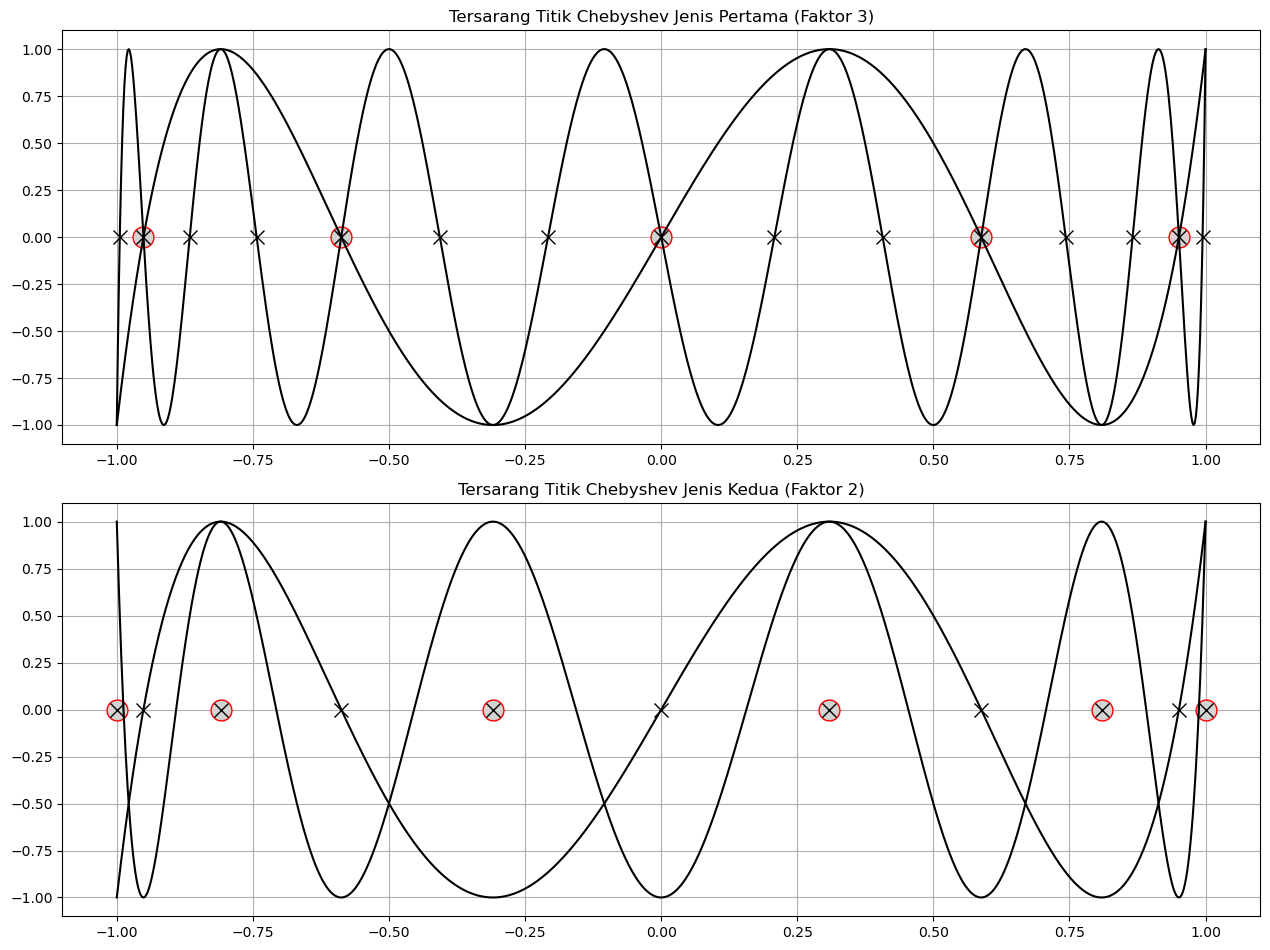

In [10]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

# Tersarang jenis pertama (faktor 3)
fig = plt.figure()                                                                            # membuat objek figure baru
fig.set_figwidth(fig.get_figwidth() * 2)                                                      # memperlebar figure menjadi dua kali ukuran default
fig.set_figheight(fig.get_figheight() * 2)                                                    # mempertinggi figure menjadi dua kali ukuran default
axes = fig.add_subplot(2, 1, 1)                                                               # menambahkan subplot pertama di bagian atas

N = 5                                                                                         # menetapkan jumlah titik Chebyshev awal
factor = 3                                                                                    # menetapkan faktor tersarang untuk jenis pertama yaitu 3
x_1 = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)                # menghitung N titik Chebyshev jenis pertama pada resolusi awal
x_2 = numpy.cos((2.0 * numpy.arange(1, factor * N + 1) - 1.0) / (2.0 * factor * N) * numpy.pi)  # menghitung titik Chebyshev jenis pertama pada resolusi tiga kali lipat

axes.plot(x_1, numpy.zeros(N), "o", color="r", markerfacecolor="lightgray", markersize=15)   # memplot titik-titik resolusi awal dengan lingkaran merah berisi abu-abu
axes.plot(x_2, numpy.zeros(N * factor), 'kx', markersize=10)                                 # memplot titik-titik resolusi tinggi dengan tanda silang hitam

x_hat = numpy.linspace(-1, 1, 1000)                                                           # membuat array titik evaluasi halus dari -1 sampai 1
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')                                               # memplot polinomial Chebyshev ke-(N+1) pada resolusi awal
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')                                      # memplot polinomial Chebyshev ke-(3N+1) pada resolusi tinggi
axes.set_xlim((-1.1, 1.1))                                                                    # menetapkan batas sumbu x dari -1.1 sampai 1.1
axes.set_ylim((-1.1, 1.1))                                                                    # menetapkan batas sumbu y dari -1.1 sampai 1.1
axes.set_title("Tersarang Titik Chebyshev Jenis Pertama (Faktor 3)")                          # memberikan judul subplot pertama
axes.grid(True)                                                                               # menampilkan grid pada subplot pertama

# Tersarang jenis kedua (faktor 2)
axes = fig.add_subplot(2, 1, 2)                                                               # menambahkan subplot kedua di bagian bawah
N = 5                                                                                         # menetapkan kembali jumlah titik Chebyshev awal
factor = 2                                                                                    # menetapkan faktor tersarang untuk jenis kedua yaitu 2
x_1 = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)                                          # menghitung N+1 titik Chebyshev jenis kedua pada resolusi awal
x_2 = numpy.cos(numpy.arange(factor * N + 1) * numpy.pi / (factor * N))                      # menghitung titik Chebyshev jenis kedua pada resolusi dua kali lipat

axes.plot(x_1, numpy.zeros(N + 1), "o", color="r", markerfacecolor="lightgray", markersize=15)  # memplot titik-titik resolusi awal dengan lingkaran merah berisi abu-abu
axes.plot(x_2, numpy.zeros(N * factor + 1), 'kx', markersize=10)                             # memplot titik-titik resolusi tinggi dengan tanda silang hitam

axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')                                               # memplot polinomial Chebyshev ke-(N+1) pada resolusi awal
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')                                      # memplot polinomial Chebyshev ke-(2N+1) pada resolusi tinggi
axes.set_xlim((-1.1, 1.1))                                                                    # menetapkan batas sumbu x dari -1.1 sampai 1.1
axes.set_ylim((-1.1, 1.1))                                                                    # menetapkan batas sumbu y dari -1.1 sampai 1.1
axes.set_title("Tersarang Titik Chebyshev Jenis Kedua (Faktor 2)")                            # memberikan judul subplot kedua
axes.grid(True)                                                                               # menampilkan grid pada subplot kedua

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

Salah satu cara untuk mengukur optimalitas titik-titik Chebyshev sebagai titik interpolasi adalah dengan mempertimbangkan fungsi Lebesgue:
$$
\lambda_N(x) = \sum_{i=0}^N\big{|}\ell_i(x)\big{|}
$$
di mana $\ell_i(x)$ adalah fungsi basis Lagrange untuk sekumpulan titik $x_i$ yang diberikan. Nilai maksimum dari fungsi Lebesgue disebut $\Lambda_N$ yaitu konstanta Lebesgue, yang jelas berkaitan dengan interpolasi Lagrange karena memberikan estimasi pertama untuk galat interpolasi.

Sayangnya, $\Lambda_N$ tidak terbatas secara seragam terlepas dari titik-titik yang digunakan, karena dapat ditunjukkan bahwa:
$$
    \Lambda_N > \mathcal{O}(\log N) \quad \text{saat} \quad N \rightarrow \infty
$$
Perlu dicatat bahwa $\Lambda_N$ adalah norma tak hingga dari operator linear yang memetakan data ke interpolan pada grid dan interval yang diberikan.

Jika kita menghitung fungsi-fungsi ini untuk titik-titik berjarak sama dan masing-masing jenis titik Chebyshev, kita dapat melihat mengapa Chebyshev bisa jauh lebih baik untuk interpolasi dibandingkan titik-titik berjarak sama.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17396\3824642836.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[i].set_ylim((0.0, y_max + 0.1))                                                      # menetapkan batas sumbu y yang sama untuk semua subplot


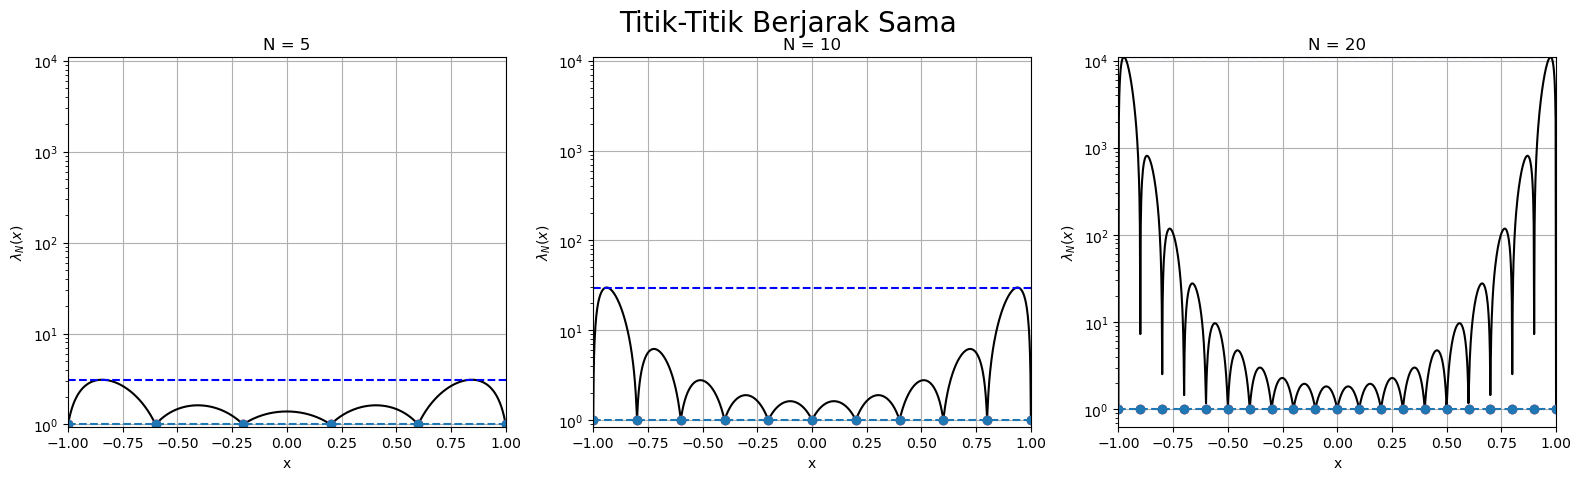

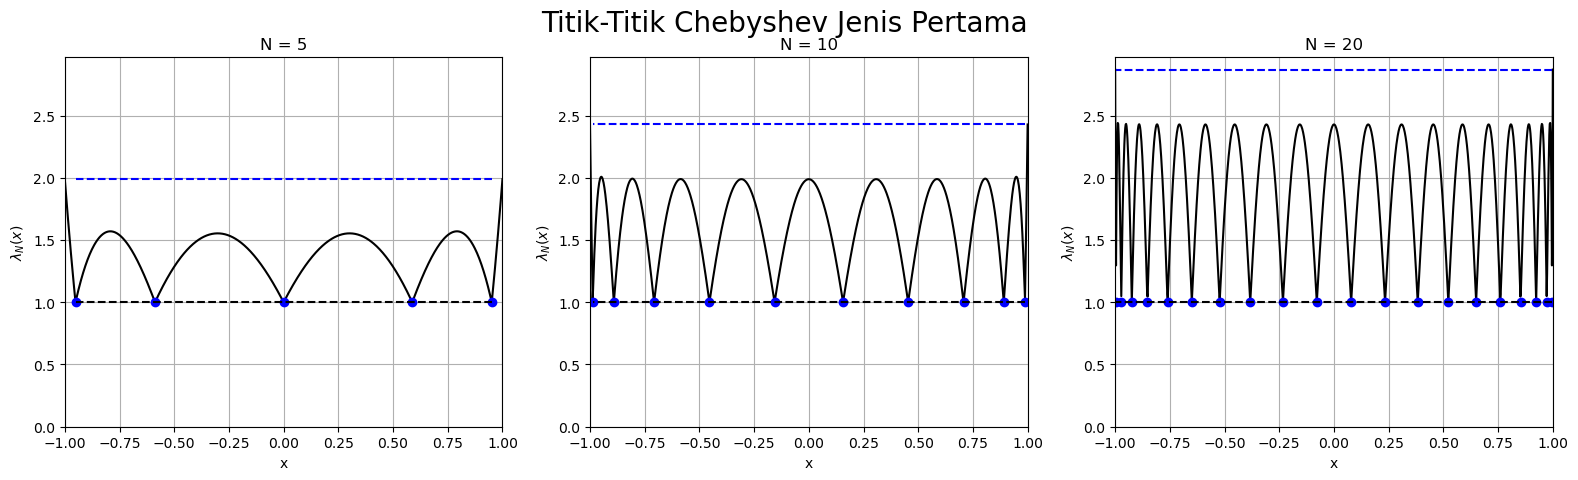

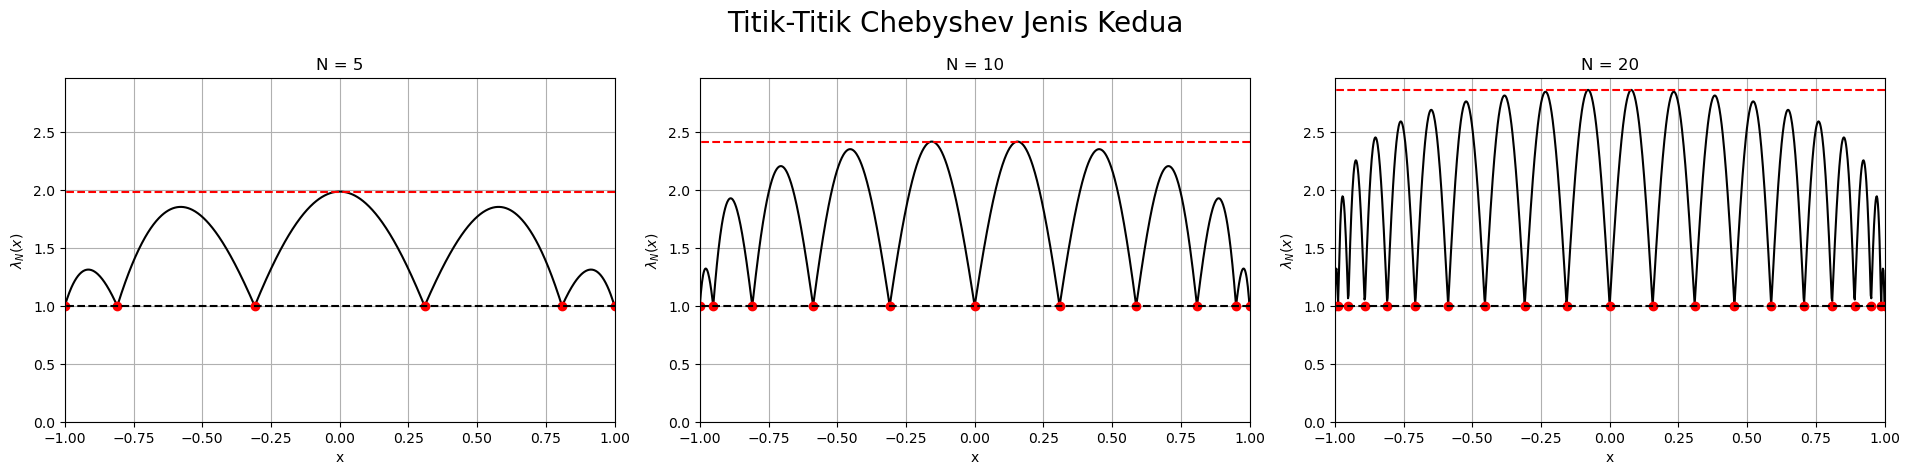

In [11]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

def lebesgue(x, data):                                                                        # mendefinisikan fungsi untuk menghitung fungsi Lebesgue
    """Compute the *i*th Lagrangian basis
    
    :Input:
     - *x* (numpy.ndarray) x values that basis will be evaluated at
     - *data* (numpy.ndarray) Tuples representing interpolant points
     - *i* (int) Which basis function to compute.
     
    :Output:
     - (numpy.ndarray) Contains the ith Lagrangian basis evaluated at x
    """
    lebesgue = numpy.zeros(x.shape[0])                                                        # membuat array nol untuk menyimpan nilai fungsi Lebesgue di setiap titik x
    for i in range(data.shape[0]):                                                            # melakukan iterasi untuk setiap basis Lagrange ke-i
        lagrange_basis = numpy.ones(x.shape[0])                                               # menginisialisasi basis Lagrange ke-i dengan nilai satu di semua titik
        for j in range(data.shape[0]):                                                        # melakukan iterasi untuk setiap faktor dalam produk basis Lagrange
            if i != j:                                                                        # melewati suku ketika indeks i sama dengan j agar tidak dibagi nol
                lagrange_basis *= (x - data[j]) / (data[i] - data[j])                        # mengalikan faktor basis Lagrange ke-i di semua titik evaluasi
        lebesgue += numpy.abs(lagrange_basis)                                                 # menambahkan nilai absolut basis ke-i ke fungsi Lebesgue
    return lebesgue                                                                           # mengembalikan array berisi nilai fungsi Lebesgue di setiap titik x

N_range = [5, 10, 20]                                                                         # menetapkan daftar jumlah titik interpolasi yang akan dibandingkan
x = numpy.linspace(-1, 1, 1000)                                                               # membuat array titik evaluasi halus sebanyak 1000 titik dari -1 sampai 1

# ============================================================
# Titik-titik berjarak sama (Equispaced)
fig = plt.figure()                                                                            # membuat figure baru untuk plot titik berjarak sama
fig.set_figwidth(fig.get_figwidth() * 3)                                                      # memperlebar figure menjadi tiga kali ukuran default
fig.suptitle("Titik-Titik Berjarak Sama", fontsize=20)                                        # memberikan judul utama figure
y_max = 0.0                                                                                   # menginisialisasi nilai maksimum y untuk penyeragaman batas sumbu
axes = []                                                                                     # membuat list kosong untuk menyimpan objek subplot
for (i, N) in enumerate([5, 10, 20]):                                                         # melakukan iterasi untuk setiap nilai N yaitu 5, 10, dan 20
    x_hat = -1.0 + 2.0 * numpy.arange(N + 1) / N                                             # menghitung N+1 titik berjarak sama dari -1 sampai 1
    y = lebesgue(x, x_hat)                                                                   # menghitung fungsi Lebesgue untuk titik-titik berjarak sama
    axes.append(fig.add_subplot(1, 3, i + 1))                                                 # menambahkan subplot ke-i ke dalam figure
    axes[i].semilogy(x, y, 'k')                                                              # memplot fungsi Lebesgue dengan skala logaritmik sumbu y menggunakan garis hitam
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'ro')                                         # memplot titik-titik interpolasi pada y=1 dengan lingkaran merah
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'o--')                                        # menghubungkan titik-titik interpolasi dengan garis putus-putus
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'b--')                             # menggambar garis horizontal biru di nilai maksimum fungsi Lebesgue
    axes[i].set_xlim((-1, 1))                                                                 # menetapkan batas sumbu x dari -1 sampai 1
    axes[i].set_title(f"N = {N}")                                                             # memberikan judul subplot dengan nilai N yang sesuai
    axes[i].set_xlabel("x")                                                                   # memberikan label sumbu x
    axes[i].set_ylabel("$\\lambda_N(x)$")                                                    # memberikan label sumbu y dengan notasi LaTeX
    axes[i].grid(True)                                                                        # menampilkan grid pada setiap subplot
    y_max = max(y_max, numpy.max(y))                                                          # memperbarui nilai maksimum y jika ditemukan nilai yang lebih besar
for i in range(len(N_range)):                                                                 # melakukan iterasi untuk menyeragamkan batas sumbu y semua subplot
    axes[i].set_ylim((0.0, y_max + 0.1))                                                      # menetapkan batas sumbu y yang sama untuk semua subplot

# ============================================================
# Titik-titik Chebyshev jenis pertama
fig = plt.figure()                                                                            # membuat figure baru untuk plot titik Chebyshev jenis pertama
fig.set_figwidth(fig.get_figwidth() * 3)                                                      # memperlebar figure menjadi tiga kali ukuran default
fig.suptitle("Titik-Titik Chebyshev Jenis Pertama", fontsize=20)                              # memberikan judul utama figure
y_max = 0.0                                                                                   # menginisialisasi kembali nilai maksimum y
axes = []                                                                                     # membuat kembali list kosong untuk menyimpan objek subplot
for (i, N) in enumerate(N_range):                                                             # melakukan iterasi untuk setiap nilai N dalam N_range
    x_hat = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)          # menghitung N titik Chebyshev jenis pertama (akar)
    y = lebesgue(x, x_hat)                                                                   # menghitung fungsi Lebesgue untuk titik-titik Chebyshev jenis pertama
    axes.append(fig.add_subplot(1, 3, i + 1))                                                 # menambahkan subplot ke-i ke dalam figure
    axes[i].plot(x, y, 'k')                                                                  # memplot fungsi Lebesgue dengan skala linear menggunakan garis hitam
    axes[i].plot(x_hat, numpy.ones(N), 'bo')                                                  # memplot titik-titik Chebyshev jenis pertama pada y=1 dengan lingkaran biru
    axes[i].plot(x_hat, numpy.ones(N), 'k--')                                                 # menghubungkan titik-titik Chebyshev dengan garis putus-putus hitam
    axes[i].plot(x_hat, numpy.ones(N) * numpy.max(y), 'b--')                                 # menggambar garis horizontal biru di nilai maksimum fungsi Lebesgue
    axes[i].set_xlim((-1, 1))                                                                 # menetapkan batas sumbu x dari -1 sampai 1
    axes[i].set_title(f"N = {N}")                                                             # memberikan judul subplot dengan nilai N yang sesuai
    axes[i].set_xlabel("x")                                                                   # memberikan label sumbu x
    axes[i].set_ylabel("$\\lambda_N(x)$")                                                    # memberikan label sumbu y dengan notasi LaTeX
    axes[i].grid(True)                                                                        # menampilkan grid pada setiap subplot
    y_max = max(y_max, numpy.max(y))                                                          # memperbarui nilai maksimum y jika ditemukan nilai yang lebih besar
for i in range(len(N_range)):                                                                 # melakukan iterasi untuk menyeragamkan batas sumbu y semua subplot
    axes[i].set_ylim((0.0, y_max + 0.1))                                                      # menetapkan batas sumbu y yang sama untuk semua subplot

# ============================================================
# Titik-titik Chebyshev jenis kedua (ekstrem)
fig = plt.figure()                                                                            # membuat figure baru untuk plot titik Chebyshev jenis kedua
fig.set_figwidth(fig.get_figwidth() * 3)                                                      # memperlebar figure menjadi tiga kali ukuran default
fig.suptitle("Titik-Titik Chebyshev Jenis Kedua", fontsize=20)                               # memberikan judul utama figure
y_max = 0.0                                                                                   # menginisialisasi kembali nilai maksimum y
axes = []                                                                                     # membuat kembali list kosong untuk menyimpan objek subplot
for (i, N) in enumerate(N_range):                                                             # melakukan iterasi untuk setiap nilai N dalam N_range
    x_hat = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)                                    # menghitung N+1 titik Chebyshev jenis kedua (ekstrem)
    y = lebesgue(x, x_hat)                                                                   # menghitung fungsi Lebesgue untuk titik-titik Chebyshev jenis kedua
    axes.append(fig.add_subplot(1, 3, i + 1))                                                 # menambahkan subplot ke-i ke dalam figure
    axes[i].plot(x, y, 'k')                                                                  # memplot fungsi Lebesgue dengan skala linear menggunakan garis hitam
    axes[i].plot(x_hat, numpy.ones(N + 1), 'ro')                                             # memplot titik-titik Chebyshev jenis kedua pada y=1 dengan lingkaran merah
    axes[i].plot(x_hat, numpy.ones(N + 1), 'k--')                                            # menghubungkan titik-titik Chebyshev dengan garis putus-putus hitam
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'r--')                             # menggambar garis horizontal merah di nilai maksimum fungsi Lebesgue
    axes[i].set_xlim((-1, 1))                                                                 # menetapkan batas sumbu x dari -1 sampai 1
    axes[i].set_title(f"N = {N}")                                                             # memberikan judul subplot dengan nilai N yang sesuai
    axes[i].set_xlabel("x")                                                                   # memberikan label sumbu x
    axes[i].set_ylabel("$\\lambda_N(x)$")                                                    # memberikan label sumbu y dengan notasi LaTeX
    axes[i].grid(True)                                                                        # menampilkan grid pada setiap subplot
    y_max = max(y_max, numpy.max(y))                                                          # memperbarui nilai maksimum y jika ditemukan nilai yang lebih besar
for i in range(len(N_range)):                                                                 # melakukan iterasi untuk menyeragamkan batas sumbu y semua subplot
    axes[i].set_ylim((0.0, y_max + 0.1))                                                      # menetapkan batas sumbu y yang sama untuk semua subplot

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

Untuk benar-benar menunjukkan bahwa titik-titik Chebyshev bersifat optimal, perhatikan polinomial monik $p(z)$ di bidang kompleks dengan derajat $N$:
$$
    p(z) = \prod^N_{k=1} (z - z_k)
$$
di mana $z_k$ adalah akar-akar dengan kemungkinan multiplisitas yang tidak trivial. Dengan sedikit manipulasi, kita juga dapat menuliskan ekspresi-ekspresi berikut yang saling berkaitan:
$$\begin{aligned}
    |p(z)| &= \prod^N_{k=1} |z - z_k| \\
    \log|p(z)| &= \sum^N_{k=1} \log|z - z_k|.
\end{aligned}$$
Persamaan pertama menyatakan bahwa nilai absolut polinomial adalah hasil kali jarak dari $z$ ke setiap akar, sedangkan persamaan kedua menyatakan hal yang sama dalam bentuk logaritmik sehingga perkalian berubah menjadi penjumlahan. Bentuk logaritmik ini sangat berguna karena berkaitan dengan konsep fungsi Green dan teori potensial dalam analisis kompleks.

Misalkan:
$$
    \phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - z_k|
$$
Karena $\phi_N(z)$ bersifat *harmonik*, ia memenuhi persamaan Laplace di bidang kompleks kecuali di titik-titik akar $z_k$. Pengaturan ini dapat dipandang sebagai potensial elektrostatik dengan muatan-muatan yang terletak di titik-titik akar $z_k$. Potensial dari masing-masing muatan adalah:
$$
    \frac{\log |z - z_k|}{N}
$$
Dengan kata lain, setiap akar $z_k$ berlaku seperti sebuah muatan listrik titik, dan $\phi_N(z)$ adalah total potensial yang dihasilkan oleh seluruh muatan tersebut. Analogi elektrostatik ini sangat berguna karena memungkinkan kita menggunakan hasil-hasil dari teori potensial untuk memahami distribusi optimal titik-titik interpolasi.

Sekarang perhatikan hubungan antara $|p(z)|$ dan $\phi_N(z)$. Dari ekspresi sebelumnya kita tahu bahwa:
$$
    |p(z)| = e^{N \phi_N(z)}
$$
Jika $\phi_N(z)$ kira-kira konstan pada interval $[-1, 1]$, maka $|p(z)|$ juga akan konstan. Sebaliknya, jika $\phi_N(z)$ bervariasi, maka variasi $|p(z)|$ akan bersifat eksponensial, terutama untuk nilai $N$ yang besar!

Dengan memperhatikan perilaku ini, perhatikan limit $N \rightarrow \infty$ dan anggap titik-titik $x_j$ terdistribusi di $[-1, 1]$ sesuai dengan fungsi kerapatan $\rho(x)$ dengan syarat normalisasi:
$$
    \int^1_{-1} \rho(x) dx = 1
$$
Syarat normalisasi ini memastikan bahwa $\rho(x)$ adalah fungsi kerapatan probabilitas yang valid, sehingga total "muatan" yang tersebar di interval $[-1, 1]$ bernilai satu. Tujuan kita adalah mencari distribusi $\rho(x)$ yang membuat $\phi_N(z)$ sekonstanta mungkin pada interval tersebut, karena itulah yang akan meminimalkan variasi $|p(z)|$ dan menghasilkan interpolasi yang paling akurat.

Dari fungsi kerapatan ini, kita juga dapat mengetahui jumlah titik grid dalam interval $[a, b]$ yaitu:
$$
    1 = N \int^b_a \rho(x) dx
$$

Dengan kerangka ini kita dapat menuliskan potensial sebagai:
$$
    \phi(z) = \int^1_{-1} \rho(x) \log |z - x| dx
$$
Pada limit $N \rightarrow \infty$, dapat ditunjukkan untuk titik-titik berjarak sama bahwa:
$$
    \phi(z) = -1 + \frac{1}{2} \Re((z + 1) \log(z + 1) - (z-1)\log(z-1))
$$
Perhatikan bahwa $\phi(0) = -1$ dan $\phi(\pm 1) = -1 + \log 2$, yang berarti jika sebuah polinomial $p$ memiliki akar-akar berjarak sama di $[-1, 1]$, maka nilainya akan $2^N$ kali lebih besar di dekat titik $\pm 1$ dibandingkan di dekat titik $0$. Inilah yang menyebabkan fenomena Runge pada titik-titik berjarak sama — variasi potensial yang besar mengakibatkan osilasi eksponensial di dekat ujung domain.

Sebaliknya, jika kita mempertimbangkan distribusi untuk titik-titik Chebyshev:
$$
    \rho(x) = \frac{1}{\pi \sqrt{1 - x^2}}, \quad x\in[-1,1]
$$
dapat ditunjukkan bahwa potensial yang dihasilkan adalah:
$$
    \phi(z) = \log\frac{\left|z - \sqrt{z^2 - 1} \right |}{2}
$$
Distribusi Chebyshev ini lebih rapat di dekat ujung domain ($x = \pm 1$) dan lebih jarang di tengah, yang secara tepat mengimbangi kecenderungan polinomial untuk berosilasi lebih besar di dekat ujung interval.

Menariknya, rumus-rumus ini memiliki interpretasi yang sederhana: kurva-kurva level dari $\phi(z)$ adalah elips-elips dengan fokus di $\pm 1$. Nilai $\phi(z)$ di sepanjang elips manapun adalah logaritma dari setengah jumlah sumbu semi-mayor dan semi-minor elips tersebut. Elips yang terdegenerasi yaitu $[-1, 1]$ juga merupakan kurva level dan mengambil nilai konstan $-\log 2$.

Ini ternyata bersifat optimal, dengan polinomial yang tumbuh sebagai:
$$
    |p(z)| = e^{N \phi(x)} \approx 2^{-N}, ~~~ x\in[-1,1]
$$
Artinya, polinomial monik dengan akar-akar di titik Chebyshev memiliki nilai absolut yang seragam dan sangat kecil (mengecil secara eksponensial sebesar $2^{-N}$) di seluruh interval $[-1, 1]$. Tidak ada pilihan titik lain yang dapat menghasilkan nilai maksimum yang lebih kecil dari ini, itulah mengapa titik-titik Chebyshev disebut optimal sebagai titik interpolasi.

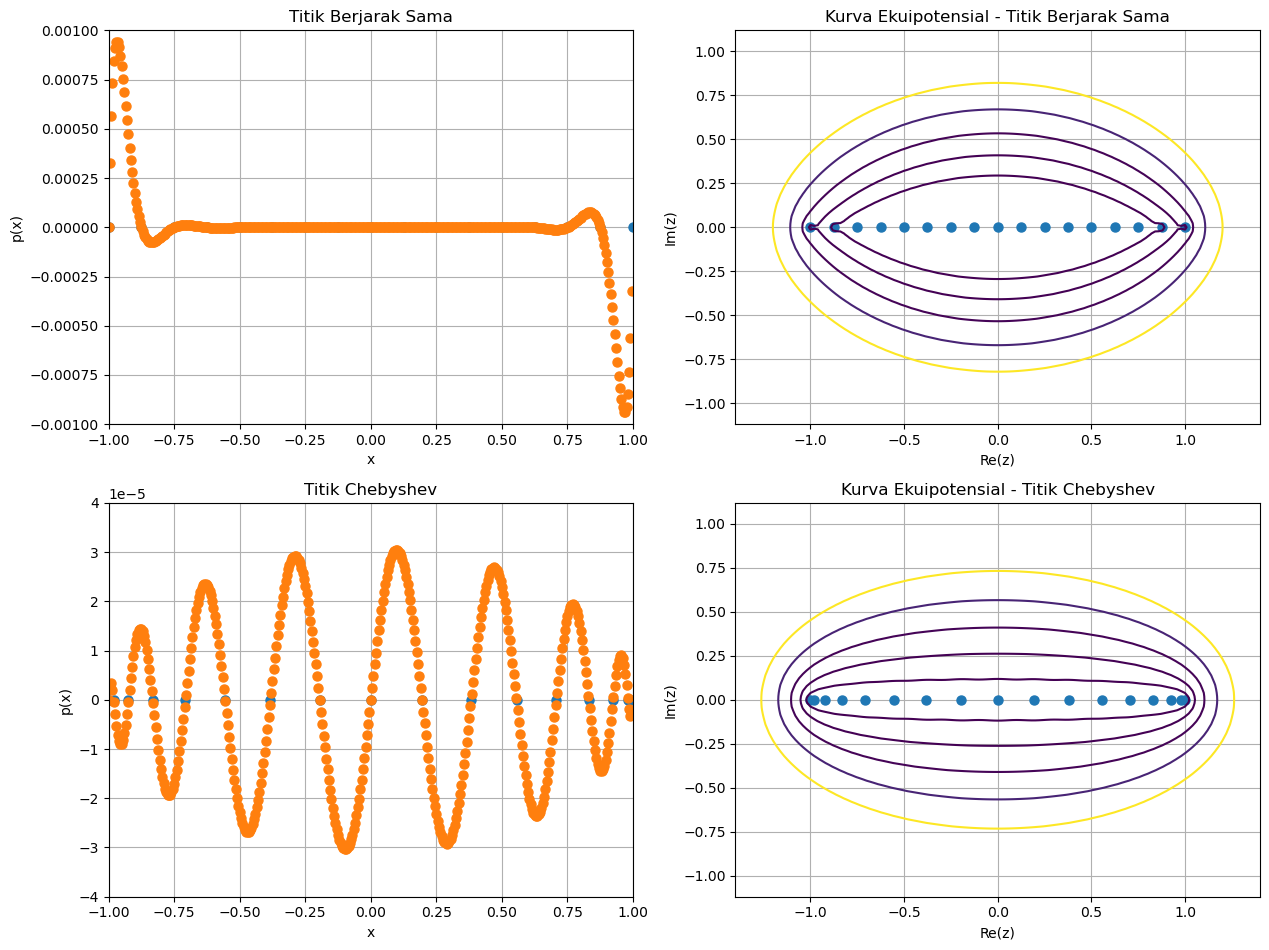

In [12]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

# Diadaptasi dari program 10 dalam Trefethen - "Spectral Methods for MATLAB"
N = 16                                                                                        # menetapkan derajat polinomial yaitu jumlah akar yang akan digunakan

fig, axes = plt.subplots(2, 2)                                                                # membuat figure dengan empat subplot bersusunan 2 baris dan 2 kolom
fig.set_figwidth(fig.get_figwidth() * 2)                                                      # memperlebar figure menjadi dua kali ukuran default
fig.set_figheight(fig.get_figheight() * 2)                                                    # mempertinggi figure menjadi dua kali ukuran default

for (i, point_distribution) in enumerate(("Titik Berjarak Sama", "Titik Chebyshev")):        # melakukan iterasi untuk dua jenis distribusi titik
    if i == 0:                                                                                # memeriksa apakah iterasi saat ini adalah untuk titik berjarak sama
        x = -1.0 + 2.0 * numpy.arange(N + 1) / N                                            # menghitung N+1 titik berjarak sama dari -1 sampai 1
    else:                                                                                     # jika bukan titik berjarak sama maka gunakan titik Chebyshev
        x = numpy.cos(numpy.pi * numpy.arange(N + 1) / N)                                    # menghitung N+1 titik Chebyshev jenis kedua (ekstrem) dari -1 sampai 1

    p = numpy.poly(x)                                                                         # membangun polinomial monik dengan akar-akar di titik-titik x

    x_fine = numpy.arange(-1, 1, 0.005)                                                       # membuat array titik evaluasi halus dari -1 sampai 1 dengan jarak 0.005
    axes[i, 0].plot(x, 0 * x, '.', markersize=13)                                            # memplot posisi titik-titik akar pada sumbu x (y=0)
    axes[i, 0].plot(x_fine, numpy.polyval(p, x_fine), '.', markersize=13)                    # memplot nilai polinomial p(x) di titik-titik evaluasi halus
    axes[i, 0].grid(True)                                                                     # menampilkan grid pada subplot kiri
    axes[i, 0].set_title(point_distribution)                                                  # memberikan judul subplot kiri sesuai jenis distribusi titik
    axes[i, 0].set_xlabel("x")                                                               # memberikan label sumbu x
    axes[i, 0].set_ylabel("p(x)")                                                            # memberikan label sumbu y sebagai nilai polinomial
    axes[i, 0].set_xlim((-1, 1))                                                             # menetapkan batas sumbu x dari -1 sampai 1
    if i == 0:                                                                               # memeriksa apakah subplot saat ini adalah untuk titik berjarak sama
        axes[i, 0].set_ylim((-1e-3, 1e-3))                                                   # menetapkan batas sumbu y lebih lebar karena osilasi titik berjarak sama lebih besar
    else:                                                                                     # jika subplot untuk titik Chebyshev gunakan batas sumbu y yang lebih sempit
        axes[i, 0].set_ylim((-4e-5, 4e-5))                                                   # menetapkan batas sumbu y lebih sempit karena polinomial Chebyshev lebih kecil

    axes[i, 1].plot(x.real, x.imag, '.', markersize=13)                                      # memplot posisi akar-akar polinomial di bidang kompleks
    axes[i, 1].set_xlim((-1.4, 1.4))                                                         # menetapkan batas sumbu x bidang kompleks
    axes[i, 1].set_ylim((-1.12, 1.12))                                                       # menetapkan batas sumbu y bidang kompleks
    X, Y = numpy.meshgrid(numpy.arange(-1.4, 1.4, 0.02),                                     # membuat grid titik di bidang kompleks untuk arah real
                          numpy.arange(-1.12, 1.12, 0.02))                                   # membuat grid titik di bidang kompleks untuk arah imajiner
    levels = 10 ** (numpy.arange(-4.0, 1.0))                                                  # menetapkan level kontur dari 10^-4 sampai 10^0 dalam skala logaritmik
    axes[i, 1].contour(X, Y, numpy.abs(numpy.polyval(p, X + 1j * Y)), levels)                # memplot kurva ekuipotensial dari nilai absolut polinomial di bidang kompleks
    axes[i, 1].set_title(f"Kurva Ekuipotensial - {point_distribution}")                      # memberikan judul subplot kanan sesuai jenis distribusi titik
    axes[i, 1].set_xlabel("Re(z)")                                                           # memberikan label sumbu x sebagai bagian real bilangan kompleks
    axes[i, 1].set_ylabel("Im(z)")                                                           # memberikan label sumbu y sebagai bagian imajiner bilangan kompleks
    axes[i, 1].grid(True)                                                                    # menampilkan grid pada subplot kanan

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

### Diferensiasi Chebyshev

Salah satu cara untuk menurunkan beda hingga (*finite differences*) adalah dengan menginterpolasi polinomial melalui titik-titik stensil dan mengambil turunan dari interpolan yang dihasilkan. Kita dapat melakukan hal yang sama untuk menemukan matriks diferensiasi Chebyshev.

Karena setiap interpolan bersifat unik berdasarkan titik-titik yang dilaluinya, kita hanya perlu menentukan turunan berdasarkan titik-titik Chebyshev itu sendiri. Misalkan:
$$
   p_N(x_j) = v_j, \quad 0 \leq j \leq N
$$
adalah polinomial berderajat $N$, maka turunan yang dihasilkan adalah:
$$
    p'_N(x_j) = w_j
$$
Artinya, kita mencari hubungan linear antara nilai fungsi $v_j$ di titik-titik Chebyshev dengan nilai turunannya $w_j$ di titik-titik yang sama. Hubungan linear ini nantinya dapat dinyatakan sebagai perkalian matriks, yang disebut matriks diferensiasi Chebyshev.

Karena operasi ini bersifat linear, kita dapat menyatakannya sebagai perkalian matriks:
$$
    \mathbf{w} = \mathbf{D}_N \mathbf{v}
$$

Sebagai contoh, perhatikan kasus $N=1$, di mana titik-titik interpolasi adalah $x_0 = 1$ dan $x_1 = -1$, sehingga:
$$
    p_1(x) = \frac{1}{2} (1  + x)v_0 + \frac{1}{2}(1 - x)v_1
$$
yang menghasilkan turunan:
$$
    p'_1(x) = \frac{1}{2}(v_0 - v_1)
$$
Matriks diferensiasi yang dihasilkan adalah:
$$
    D_1 = \begin{bmatrix}
        1/2 & -1/2 \\
        1/2 & -1/2
    \end{bmatrix}
$$

Untuk kasus $N=2$, kita memiliki titik-titik $x_0 = 1$, $x_1 = 0$, dan $x_2 = -1$ dengan interpolan kuadratik:
$$
    p_2(x) = \frac{1}{2} x ( 1 + x) v_0 + (1+x)(1-x)v_1 + \frac{1}{2} x (x-1) v_2
$$
yang menghasilkan turunan:
$$
    p'_2(x) = (x+ 1/2) v_0 - 2 x v_1 + (x-1/2)v_2
$$
dan matriks diferensiasi:
$$
    D_2 = \begin{bmatrix}
        3/2  & -2 & 1/2 \\
        1/2  &  0 & -1/2 \\
        -1/2 &  2 & -3/2
    \end{bmatrix}
$$
Perhatikan bahwa matriks $D_2$ bersifat anti-simetris di luar elemen diagonal, dan elemen sudut (pojok kiri atas dan pojok kanan bawah) memiliki nilai yang lebih besar. Ini merupakan ciri khas matriks diferensiasi Chebyshev yang mencerminkan kerapatan titik-titik Chebyshev di dekat ujung domain.

Perhatikan bahwa untuk kedua kasus ini, rumus-rumusnya mengambil bentuk yang familiar, namun matriks diferensiasinya memiliki sifat satu sisi (*one sided*) tambahan. Untuk aproksimasi orde tinggi, metode ini menyimpang dari metode beda hingga biasa karena jarak titik-titik yang tidak merata. Secara umum, matriks diferensiasi Chebyshev mengambil bentuk:
$$\begin{aligned}
    (D_N)_{00} = \frac{2 N^2 + 1}{6}, & & (D_N)_{NN} = -\frac{2N^2 + 1}{6}, \\
    (D_N)_{jj} = \frac{-x_j}{2(1 - x_j^2)}, & & j=1,\ldots,N-1 \\
    (D_N)_{ij} = \frac{c_i(-1)^{i+j}}{c_j (x_i - x_j)}, & & i\neq j, ~~ i,j = 0, \ldots, N
\end{aligned}$$
di mana:
$$
    c_i = \left \{ \begin{aligned}
        2, & & i=0 \text{ atau } N \\
        1, & & \text{selainnya}.
    \end{aligned} \right .
$$
Elemen diagonal $(D_N)_{jj}$ mencerminkan kontribusi lokal dari kerapatan titik Chebyshev di setiap posisi, sedangkan elemen luar diagonal $(D_N)_{ij}$ mencerminkan pengaruh global dari semua titik lainnya. Faktor $c_i$ memberikan bobot khusus pada titik-titik ujung domain ($i=0$ dan $i=N$) karena titik-titik tersebut hanya memiliki tetangga di satu sisi saja.


In [13]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import scipy                                                                                   # import library scipy untuk komputasi ilmiah
import operator                                                                                # import modul operator untuk operasi perkalian berurutan
from functools import reduce                                                                   # import fungsi reduce untuk mengaplikasikan fungsi secara berurutan

def cheb(N):                                                                                  # mendefinisikan fungsi untuk menghitung matriks diferensiasi Chebyshev dan titik-titiknya
    x = numpy.cos(numpy.pi * numpy.arange(N + 1) / N)                                        # menghitung N+1 titik Chebyshev jenis kedua dari x=1 sampai x=-1
    e = numpy.ones((N + 1, 1))                                                                # membuat vektor kolom berisi satu sebagai pembantu operasi outer product
    Xdiff = numpy.outer(x, e) - numpy.outer(e, x) + numpy.identity(N + 1)                    # menghitung matriks selisih antar titik Chebyshev dengan diagonal satu untuk menghindari pembagian nol
    xprod = -reduce(operator.mul, Xdiff)                                                      # menghitung hasil kali semua baris Xdiff lalu mengubah tandanya untuk mendapatkan bobot barycentric
    W = numpy.outer(1.0 / xprod, e)                                                           # membuat matriks bobot barycentric dengan membagi satu terhadap hasil kali baris
    D = W / numpy.multiply(W.T, Xdiff)                                                        # menghitung elemen luar diagonal matriks diferensiasi Chebyshev
    d = 1 - numpy.sum(D, axis=0)                                                              # menghitung koreksi elemen diagonal agar setiap baris matriks berjumlah nol

    for k in range(0, N + 1):                                                                 # melakukan iterasi untuk setiap elemen diagonal matriks diferensiasi
        D[k, k] = d[k]                                                                        # menetapkan elemen diagonal ke-k dengan nilai koreksi yang telah dihitung

    return -D.T, x                                                                            # mengembalikan transpose negatif matriks diferensiasi dan array titik Chebyshev

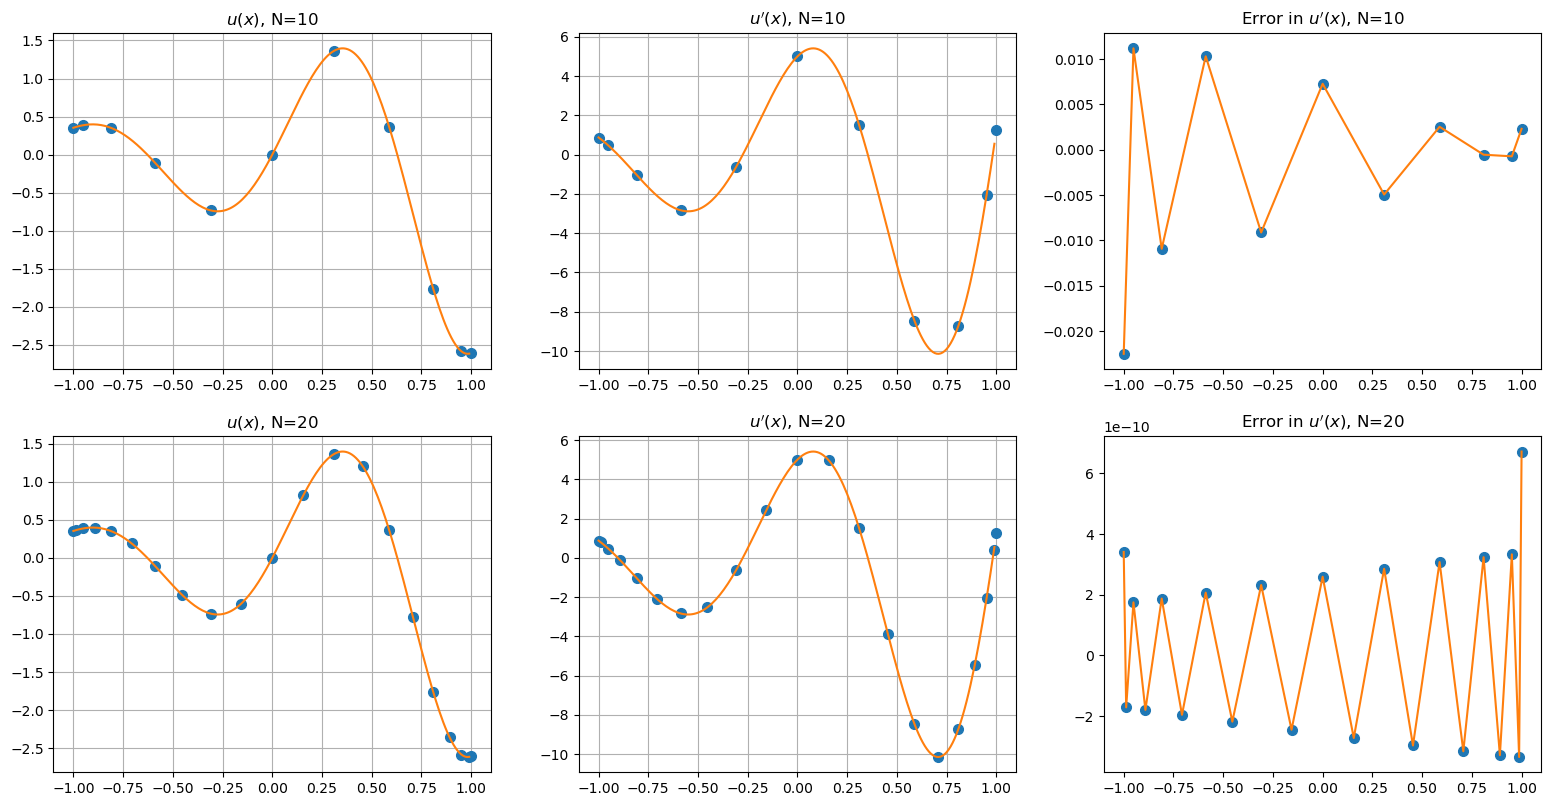

In [14]:
# Test out some differentiation on a smooth function
u = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)
u_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))

x_fine = numpy.arange(-1, 1, 0.01)
fig, axes = plt.subplots(2, 3)
fig.set_figwidth(fig.get_figwidth() * 3)
fig.set_figheight(fig.get_figheight() * 2)
for (i, N) in enumerate((10, 20)):
    D, x = cheb(N)
    axes[i, 0].plot(x, u(x), '.', markersize=14)
    axes[i, 0].grid(True)
    axes[i, 0].plot(x_fine, u(x_fine))
    axes[i, 0].set_title('$u(x)$, N=%s' % N)

    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)
    axes[i, 1].grid(True)
    axes[i, 1].plot(x_fine, u_prime(x_fine))
    axes[i, 1].set_title("$u'(x)$, N=%s" % N)
    
    error = numpy.dot(D, u(x)) - u_prime(x)
    axes[i, 2].plot(x, error, '.', markersize=14)
    axes[i, 2].plot(x, error)
    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)

plt.show()

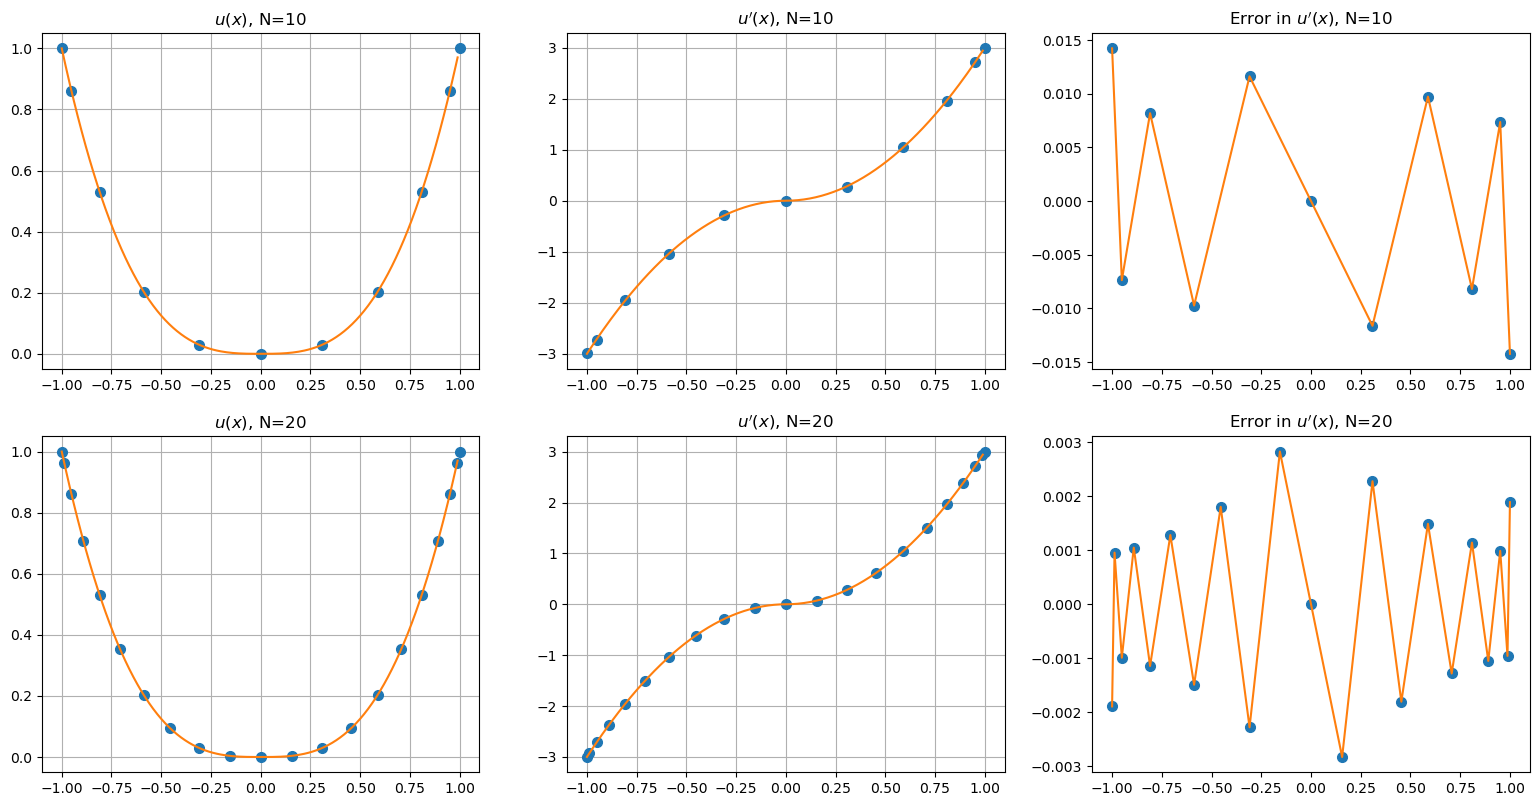

In [15]:
# Bounded Variation in 3rd derivative
u = lambda x: numpy.abs(x)**3
u_prime = lambda x: 3.0 * x * numpy.abs(x)

x_fine = numpy.arange(-1, 1, 0.01)
fig, axes = plt.subplots(2, 3)
fig.set_figwidth(fig.get_figwidth() * 3)
fig.set_figheight(fig.get_figheight() * 2)
for (i, N) in enumerate((10, 20)):
    D, x = cheb(N)
    axes[i, 0].plot(x, u(x), '.', markersize=14)
    axes[i, 0].grid(True)
    axes[i, 0].plot(x_fine, u(x_fine))
    axes[i, 0].set_title('$u(x)$, N=%s' % N)

    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)
    axes[i, 1].grid(True)
    axes[i, 1].plot(x_fine, u_prime(x_fine))
    axes[i, 1].set_title("$u'(x)$, N=%s" % N)
    
    error = numpy.dot(D, u(x)) - u_prime(x)
    axes[i, 2].plot(x, error, '.', markersize=14)
    axes[i, 2].plot(x, error)
    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)

plt.show()

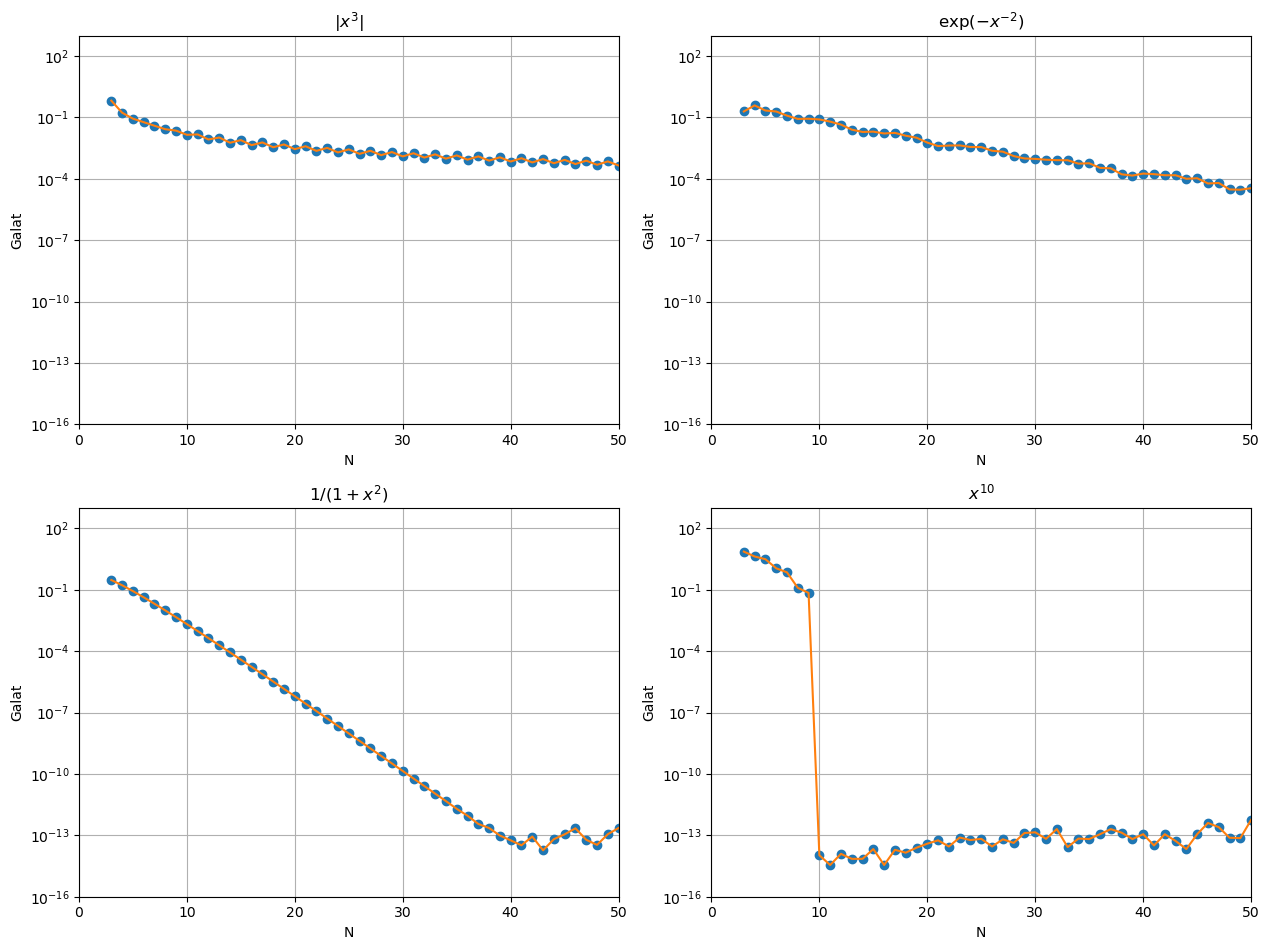

In [17]:
import numpy                                                                                    # import library numpy untuk komputasi numerik
import matplotlib.pyplot as plt                                                                # import matplotlib untuk membuat grafik

N_max = 50                                                                                    # menetapkan nilai maksimum N yang akan diuji
error = numpy.zeros((4, N_max - 2))                                                           # membuat array nol berukuran 4 x (N_max-2) untuk menyimpan galat keempat fungsi
N_range = numpy.arange(3, N_max + 1)                                                          # membuat array nilai N dari 3 sampai N_max

for (i, N) in enumerate(N_range):                                                             # melakukan iterasi untuk setiap nilai N dalam N_range
    D, x = cheb(N)                                                                            # menghitung matriks diferensiasi Chebyshev dan titik-titik Chebyshev untuk N titik

    v = numpy.abs(x)**3                                                                       # mendefinisikan fungsi |x|^3 yang memiliki turunan ketiga dengan variasi terbatas
    v_prime = numpy.abs(x) * x * 3.0                                                          # menghitung turunan eksak dari |x|^3 yaitu 3x|x|
    error[0, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)                # menghitung galat maksimum turunan spektral terhadap turunan eksak fungsi |x|^3

    v = numpy.exp(-x**(-2))                                                                   # mendefinisikan fungsi C-infinity exp(-1/x^2) yang halus namun tidak analitik di x=0
    v_prime = 2 * v / x**3                                                                    # menghitung turunan eksak dari exp(-1/x^2) yaitu 2*exp(-1/x^2)/x^3
    error[1, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)                # menghitung galat maksimum turunan spektral terhadap turunan eksak fungsi C-infinity

    v = 1.0 / (1.0 + x**2)                                                                   # mendefinisikan fungsi analitik 1/(1+x^2) yang analitik pada seluruh interval [-1,1]
    v_prime = -2.0 * x * v**2                                                                 # menghitung turunan eksak dari 1/(1+x^2) yaitu -2x/(1+x^2)^2
    error[2, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)                # menghitung galat maksimum turunan spektral terhadap turunan eksak fungsi analitik

    v = x**10                                                                                 # mendefinisikan fungsi polinomial x^10 yang seharusnya dapat didiferensiasi secara eksak
    v_prime = 10 * x**9                                                                       # menghitung turunan eksak dari x^10 yaitu 10x^9
    error[3, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)                # menghitung galat maksimum turunan spektral terhadap turunan eksak fungsi polinomial

fig = plt.figure()                                                                            # membuat objek figure baru
fig.set_figwidth(fig.get_figwidth() * 2)                                                      # memperlebar figure menjadi dua kali ukuran default
fig.set_figheight(fig.get_figheight() * 2)                                                    # mempertinggi figure menjadi dua kali ukuran default

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^{10}$']                    # menetapkan judul setiap subplot dengan notasi LaTeX yang diperbaiki

for (i, title) in enumerate(titles):                                                          # melakukan iterasi untuk setiap fungsi dan judulnya
    axes = fig.add_subplot(2, 2, i + 1)                                                       # menambahkan subplot ke-i ke dalam figure bersusunan 2x2
    axes.semilogy(N_range, error[i, :], '.', markersize=12)                                   # memplot galat dengan skala logaritmik sumbu y menggunakan titik-titik
    axes.semilogy(N_range, error[i, :])                                                       # memplot garis penghubung antar titik galat dengan skala logaritmik
    axes.set_xlim((0, N_max))                                                                 # menetapkan batas sumbu x dari 0 sampai N_max
    axes.set_ylim((1e-16, 1e3))                                                               # menetapkan batas sumbu y dari 10^-16 sampai 10^3
    axes.grid(True)                                                                           # menampilkan grid pada setiap subplot
    axes.set_xlabel("N")                                                                      # memberikan label sumbu x sebagai jumlah titik N
    axes.set_ylabel("Galat")                                                                  # memberikan label sumbu y sebagai nilai galat
    axes.set_title(title)                                                                     # memberikan judul subplot sesuai nama fungsi yang diuji

plt.tight_layout()                                                                            # mengatur tata letak agar semua elemen tidak saling bertumpuk
plt.show()                                                                                    # menampilkan semua plot yang telah dibuat

Sebagai aplikasi lain dari matriks diferensiasi Chebyshev, kita juga dapat menggunakannya untuk menghitung solusi dari masalah Poisson dengan kondisi batas non-periodik. Pertimbangkan masalah berikut:

$$
u_{xx} = e^{4x}, \quad \Omega = [-1, 1], \quad u(\pm 1) = 0
$$

yang memiliki solusi:

$$
u(x) = \frac{e^{4x} - x \sinh(4) - \cosh(4)}{16}.
$$

Dengan mengikuti langkah sebelumnya, kita memperoleh:

$$
D_N^2 U = F
$$

yang kemudian dapat diinvers untuk mendapatkan solusi.

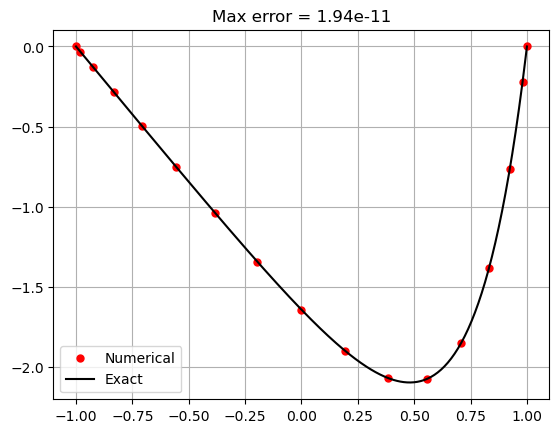

In [18]:
import numpy as np                                  # import numpy
import matplotlib.pyplot as plt                     # import matplotlib

def cheb(N):                                        # fungsi matriks Chebyshev
    if N == 0:                                      # jika N = 0
        return np.array([[0]]), np.array([1])        # kembalikan nilai trivial
    x = np.cos(np.pi * np.arange(N + 1) / N)         # titik Chebyshev
    c = np.ones(N + 1)                              # inisialisasi vektor c
    c[0] = 2                                        # elemen pertama = 2
    c[-1] = 2                                       # elemen terakhir = 2
    c = c * (-1) ** np.arange(N + 1)                 # beri tanda alternating

    X = np.tile(x, (N + 1, 1))                      # buat matriks X
    dX = X - X.T + np.eye(N + 1)                    # selisih + hindari nol diagonal
    D = (c[:, None] / c[None, :]) / dX              # matriks diferensiasi awal
    D = D - np.diag(np.sum(D, axis=1))              # koreksi diagonal
    return D, x                                     # kembalikan D dan x

f = lambda x: np.exp(4.0 * x)                       # fungsi RHS
u_true = lambda x: (np.exp(4.0 * x) - x * np.sinh(4.0) - np.cosh(4.0)) / 16.0  # solusi eksak

N = 16                                              # jumlah grid
x_fine = np.linspace(-1, 1, 400)                    # grid halus untuk plot

D, x = cheb(N)                                      # hitung matriks Chebyshev
D2 = (D @ D)[1:-1, 1:-1]                            # turunan kedua tanpa boundary

U = np.zeros(N + 1)                                 # inisialisasi solusi
U[1:-1] = np.linalg.solve(D2, f(x[1:-1]))            # selesaikan sistem linear

error = np.linalg.norm(U - u_true(x), ord=np.inf)   # hitung error maksimum

plt.figure()                                        # buat figure
plt.plot(x, U, 'r.', markersize=10, label='Numerical')  # plot solusi numerik
plt.plot(x_fine, u_true(x_fine), 'k', label='Exact')    # plot solusi eksak
plt.grid(True)                                      # tampilkan grid
plt.legend()                                        # tampilkan legenda
plt.title(f"Max error = {error:.2e}")               # judul dengan error
plt.show()                                          # tampilkan plot

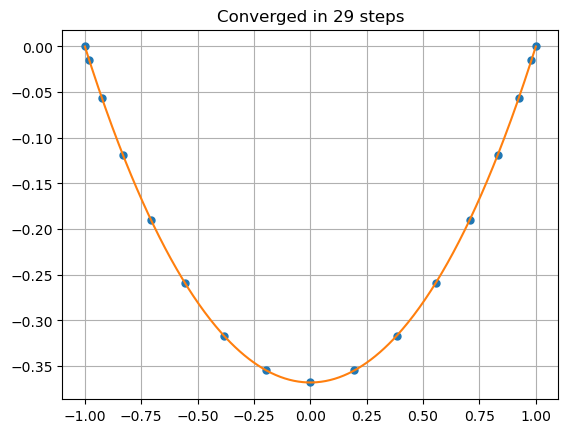

In [19]:
import numpy as np                                  # import numpy
import matplotlib.pyplot as plt                     # import matplotlib

def cheb(N):                                        # fungsi Chebyshev
    if N == 0:                                      # kasus trivial
        return np.array([[0]]), np.array([1])        # return sederhana
    x = np.cos(np.pi * np.arange(N + 1) / N)         # titik Chebyshev
    c = np.ones(N + 1)                              # inisialisasi c
    c[0] = 2; c[-1] = 2                             # ujung bernilai 2
    c = c * (-1) ** np.arange(N + 1)                 # alternating sign

    X = np.tile(x, (N + 1, 1))                      # matriks X
    dX = X - X.T + np.eye(N + 1)                    # selisih + hindari nol
    D = (c[:, None] / c[None, :]) / dX              # matriks diferensiasi
    D = D - np.diag(np.sum(D, axis=1))              # koreksi diagonal
    return D, x                                     # return hasil

f = lambda u: np.exp(u)                             # fungsi non-linear

N = 16                                              # jumlah grid
x_fine = np.linspace(-1, 1, 400)                    # grid halus

D, x = cheb(N)                                      # hitung matriks
D2 = (D @ D)[1:-1, 1:-1]                            # turunan kedua tanpa boundary

U = np.zeros(N + 1)                                 # solusi awal
delta = 1.0                                         # inisialisasi error
step = 0                                            # counter iterasi

while delta > 1e-15:                                # iterasi sampai konvergen
    U_new = U.copy()                                # salin solusi lama
    U_new[1:-1] = np.linalg.solve(D2, f(U[1:-1]))    # update interior
    delta = np.linalg.norm(U_new - U, ord=np.inf)    # hitung error maksimum
    U = U_new                                       # update solusi
    step += 1                                       # tambah iterasi

plt.figure()                                        # buat figure
plt.plot(x, U, '.', markersize=10)                  # plot titik solusi
U_interp = np.polyval(np.polyfit(x, U, N), x_fine)  # interpolasi polinomial
plt.plot(x_fine, U_interp, '-')                     # plot kurva halus
plt.grid(True)                                      # grid
plt.title(f"Converged in {step} steps")             # info iterasi
plt.show()                                          # tampilkan

Kita juga dapat menangani masalah berdimensi lebih tinggi. Pertimbangkan PDE berikut:

$$
u_{xx} + u_{yy} = 10 \sin(8 x (y - 1)), \quad -1 < x,~y < 1
$$

dengan kondisi batas $u = 0$ pada seluruh batas domain.

Kita masih dapat menggunakan matriks diferensiasi seperti yang digunakan sebelumnya. Jika kita menyusun variabel tak diketahui (unknowns) dalam urutan alami seperti sebelumnya, maka kita dapat kembali menggunakan produk Kronecker untuk membangun matriks yang diperlukan.

Sebagai contoh, jika kita mempertimbangkan kasus $N = 4$, kita memiliki matriks diferensiasi satu dimensi:

$$
D^2_4 = \begin{bmatrix}
-14 & 6 & -2 \\
4 & -6 & 4 \\
-2 & 6 & -14
\end{bmatrix}
$$

yang dapat digunakan untuk mendekati matriks pada arah $x$ dengan urutan yang telah ditentukan sebagai `kron(I, D2)`, sehingga menghasilkan:

$$
I \otimes D^2_N = \begin{bmatrix}
-14 & 6 & -2 \\
4 & -6 & 4 \\
-2 & 6 & -14 \\
& & & -14 & 6 & -2 \\
& & & 4 & -6 & 4 \\
& & & -2 & 6 & -14 \\
& & & & & & -14 & 6 & -2 \\
& & & & & & 4 & -6 & 4 \\
& & & & & & -2 & 6 & -14
\end{bmatrix}.
$$

Turunan pada arah $y$ dapat dituliskan sebagai `kron(D2, I)` sehingga menghasilkan:

$$
D^2_N \otimes I = \begin{bmatrix}
-14 &     &     &   6 &     &     &  -2 &     &     \\
    & -14 &     &     &   6 &     &     &  -2 &     \\
    &     & -14 &     &     &   6 &     &     &  -2 \\
  4 &     &     &  -6 &     &     &   4 &     &     \\
    &   4 &     &     &  -6 &     &     &   4 &     \\
    &     &   4 &     &     &  -6 &     &     &   4 \\
 -2 &     &     &   6 &     &     & -14 &     &     \\
    &  -2 &     &     &   6 &     &     & -14 &     \\
    &     &  -2 &     &     &   6 &     &     & -14 \\
\end{bmatrix}.
$$

Secara keseluruhan, kita dapat memperoleh operator Laplasian terdiskretisasi dengan menjumlahkan kedua matriks di atas:

$$
L_N = I \otimes D^2_N + D^2_N \otimes I.
$$

Kelemahan penggunaan matriks ini dibandingkan metode beda hingga (finite differences) adalah matriksnya tidak terlalu jarang (tidak sparse). Namun, jika kita dapat memanfaatkan konvergensi spektral dari metode ini, maka kita dapat menggunakan jumlah titik yang jauh lebih sedikit untuk menyelesaikan sistem.

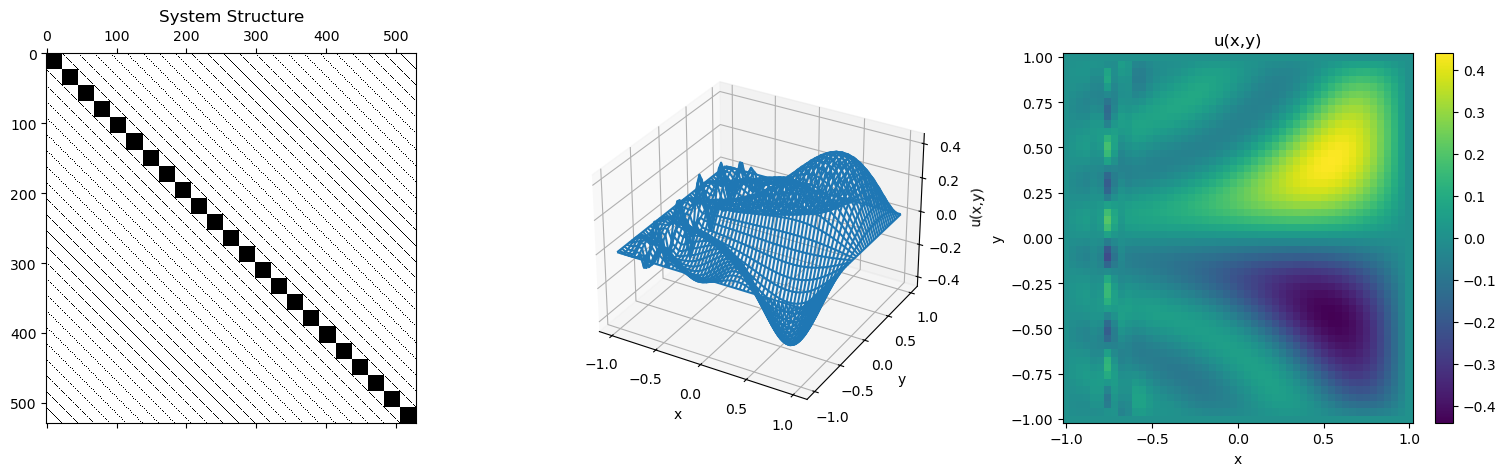

In [20]:
import numpy as np                                      # import numpy
import matplotlib.pyplot as plt                         # import matplotlib
from mpl_toolkits.mplot3d import Axes3D                 # 3D plotting
import scipy.interpolate as interp                      # interpolasi

def cheb(N):                                            # fungsi Chebyshev
    if N == 0:                                          # kasus khusus
        return np.array([[0]]), np.array([1])            # return sederhana
    x = np.cos(np.pi * np.arange(N + 1) / N)             # titik Chebyshev
    c = np.ones(N + 1)                                  # inisialisasi c
    c[0] = 2; c[-1] = 2                                 # ujung = 2
    c = c * (-1) ** np.arange(N + 1)                     # tanda selang-seling

    X = np.tile(x, (N + 1, 1))                          # matriks X
    dX = X - X.T + np.eye(N + 1)                        # selisih + hindari nol
    D = (c[:, None] / c[None, :]) / dX                  # matriks diferensiasi
    D = D - np.diag(np.sum(D, axis=1))                  # koreksi diagonal
    return D, x                                         # return D dan x

f = lambda x, y: 10.0 * np.sin(8.0 * x * (y - 1.0))     # fungsi RHS

N = 24                                                  # jumlah grid
D, x = cheb(N)                                          # matriks Chebyshev

X, Y = np.meshgrid(x[1:-1], x[1:-1])                    # grid interior
X = X.flatten()                                         # flatten X
Y = Y.flatten()                                         # flatten Y

D2 = (D @ D)[1:-1, 1:-1]                                # turunan kedua
I = np.eye(N - 1)                                       # matriks identitas
L = np.kron(I, D2) + np.kron(D2, I)                     # operator Laplacian

U = np.linalg.solve(L, f(X, Y))                         # solusi sistem linear

fig = plt.figure()                                      # buat figure
fig.set_figwidth(fig.get_figwidth() * 3)                # perbesar lebar

ax1 = fig.add_subplot(1, 3, 1)                          # subplot 1
ax1.spy(L)                                              # struktur matriks
ax1.set_title("System Structure")                       # judul

u = np.zeros((N + 1, N + 1))                            # grid solusi penuh
u[1:-1, 1:-1] = U.reshape(N - 1, N - 1)                 # isi bagian dalam

Xg, Yg = np.meshgrid(x, x)                              # grid penuh
x_fine = np.linspace(-1, 1, 50)                         # grid halus
Xf, Yf = np.meshgrid(x_fine, x_fine)                    # mesh halus

tck = interp.bisplrep(Xg, Yg, u, s=0)                   # interpolasi spline
u_fine = interp.bisplev(x_fine, x_fine, tck)            # evaluasi halus

ax2 = fig.add_subplot(1, 3, 2, projection='3d')         # subplot 2 (3D)
ax2.plot_wireframe(Xf, Yf, u_fine)                      # wireframe
ax2.set_xlabel('x')                                     # label x
ax2.set_ylabel('y')                                     # label y
ax2.set_zlabel('u(x,y)')                                # label z

ax3 = fig.add_subplot(1, 3, 3)                          # subplot 3
c = ax3.pcolor(Xf, Yf, u_fine)                          # plot warna
ax3.set_xlabel('x')                                     # label x
ax3.set_ylabel('y')                                     # label y
ax3.set_title('u(x,y)')                                 # judul
fig.colorbar(c)                                         # colorbar

plt.show()                                              # tampilkan

## FFT dan Chebyshev

FFT merupakan alat yang sangat kuat dan membuat metode spektral menjadi sangat menarik, namun sejauh ini kita baru melihat penggunaannya pada deret Fourier. Ternyata, terdapat sejumlah kesetaraan (ekivalensi) yang memungkinkan kita menggunakan FFT pada deret Chebyshev juga.

![Hubungan antara x, z, dan \theta (diadaptasi dari Trefethen fig 8.1)](./images/relationships.png)

Misalkan $z \in \mathbb{C}$ dengan $|z| = 1$, dan $\theta$ adalah argumen dari $z$, yaitu $z = e^{i \theta}$ (perlu dicatat bahwa $\theta$ hanya unik hingga kelipatan $2\pi$). Selanjutnya, $x$ adalah bagian real dari $z$ sehingga $x = \Re(z) = \cos \theta$.

Untuk setiap $x \in [-1, 1]$, terdapat dua nilai $z$ yang bersesuaian, yaitu yang diperoleh dari arah atas dan bawah pada lingkaran satuan. Hubungan tersebut diberikan oleh:

$$
x = \Re(z) = \frac{1}{2} (z + z^{-1}) = \cos \theta.
$$

Sekarang pertimbangkan polinomial Chebyshev $T_n(x)$, di mana polinomial ke-$(n+1)$ diberikan oleh:

$$
T_{n+1}(x) = \frac{1}{2} (z^{n+1} + z^{-n-1}) = \frac{1}{2} (z^n + z^{-n}) - \frac{1}{2}(z^{n-1} + z^{1-n})
$$

yang juga sesuai dengan relasi rekurensi polinomial Chebyshev:

$$
T_{n+1}(x) = 2x\,T_n(x) - T_{n-1}(x).
$$

Perlu dicatat bahwa kita sebenarnya menggunakan hubungan antara $x$ dan $z$ yang berasal dari hubungan lingkaran satuan. Karena kita juga mengetahui bahwa $T_n(x)$ adalah polinomial berderajat $n$, maka kita dapat menggunakan polinomial Chebyshev sebagai basis:

$$
p(x) = \sum_{n=0}^{\infty} a_n T_n(x), \quad x \in [-1, 1].
$$

Hal ini juga bersesuaian dengan polinomial Laurent berderajat $N$ dalam $z$ dan $z^{-1}$, sehingga $z^n$ dan $z^{-n}$ memiliki koefisien yang sama:

$$
\tilde{p}(z) = \frac{1}{2} \sum_{n=0}^{\infty} a_n (z^n + z^{-n}), \quad |z| = 1,
$$

yang juga dikenal sebagai *self-reciprocal*. Selain itu, terdapat bentuk lain berupa polinomial dalam $\theta$ yang bersifat periodik $2\pi$:

$$
P(\theta) = \sum_{n=0}^{\infty} a_n \cos(n\theta), \quad \theta \in \mathbb{R}.
$$

Lalu ke mana arah pembahasan ini? Kita mengetahui bahwa polinomial-polynomial tersebut saling ekuivalen jika hubungan antara variabel bebas $x$, $z$, dan $\theta$ seperti yang telah kita definisikan sebelumnya terpenuhi.

Sekarang, mari kita pertimbangkan bagaimana polinomial-polynomial ini berperan sebagai interpolan. Misalkan $f(x)$ adalah suatu fungsi sembarang pada interval $[-1, 1]$, maka kita dapat membentuk fungsi *self-reciprocal* $\tilde{f}(z)$ sebagai berikut:

$$
\tilde{f}(z) = f\left(\frac{1}{2}(z + z^{-1})\right)
$$

dan secara bersesuaian:

$$
F(\theta) = f(\cos \theta).
$$

Sekarang kita lihat bagaimana versi terpotong (truncated) dari polinomial ini menginterpolasi fungsi-fungsi tersebut. Titik-titik nodal dari interpolan diberikan oleh:

$$
\theta_j = \frac{j\pi}{N}, \quad z_j = e^{i\theta_j}, \quad \text{dan} \quad x_j = \cos \theta_j = \Re(z_j).
$$

Dengan ini, kita dapat menyatakan hal-hal berikut terkait polinomial terpotong tersebut terhadap fungsi $f$:

- $P(\theta)$ menginterpolasi $F(\theta)$ (dengan asumsi fungsi tersebut genap dan periodik $2\pi$) pada titik-titik berjarak sama $\theta_j$,
- $\tilde{p}(z)$ menginterpolasi $\tilde{f}(z)$ pada akar-akar satuan $z_j$,
- $p(x)$ menginterpolasi $f(x)$ pada titik-titik Chebyshev $x_j$.

Sekarang kita mulai dapat melihat bagaimana FFT dapat digunakan pada deret Chebyshev melalui kesetaraan-kesetaraan ini. Proses dasarnya adalah sebagai berikut:

1. Diberikan fungsi sembarang $f$, tentukan polinomial trigonometri interpolan $Q$ dari $F$,
2. Turunkan interpolan tersebut di ruang Fourier, dan
3. Transformasikan kembali ke domain asal pada $x \in [-1, 1]$.

In [21]:
import numpy as np                                      # import numpy
from numpy.fft import fft, ifft                         # import FFT

def chebfft(v):                                         # fungsi turunan Chebyshev via FFT
    N = v.shape[0] - 1                                  # jumlah grid - 1
    if N == 0:                                          # kasus trivial
        return 0                                        # return nol

    x = np.cos(np.arange(N + 1) * np.pi / N)            # titik Chebyshev
    ii = np.arange(N)                                   # indeks 0 sampai N-1

    V = np.hstack((v, v[N-1:0:-1]))                     # perpanjang data (simetri)
    U = fft(V).real                                     # transformasi FFT
    wave_numbers = np.hstack((ii, [0], np.arange(1 - N, 0)))  # bilangan gelombang
    W = ifft(1j * wave_numbers * U).real                # turunan di ruang Fourier

    w = np.zeros(N + 1)                                 # inisialisasi hasil

    w[1:N] = -W[1:N] / np.sqrt(1.0 - x[1:N]**2)         # kembali ke domain x
    w[0] = (np.sum(ii**2 * U[ii]) / N) + 0.5 * N * U[N] # nilai di batas kiri
    w[-1] = (np.sum((-1)**(ii + 1) * ii**2 * U[ii]) / N) \
            + 0.5 * (-1)**(N + 1) * N * U[N]            # nilai di batas kanan

    return w                                            # kembalikan turunan

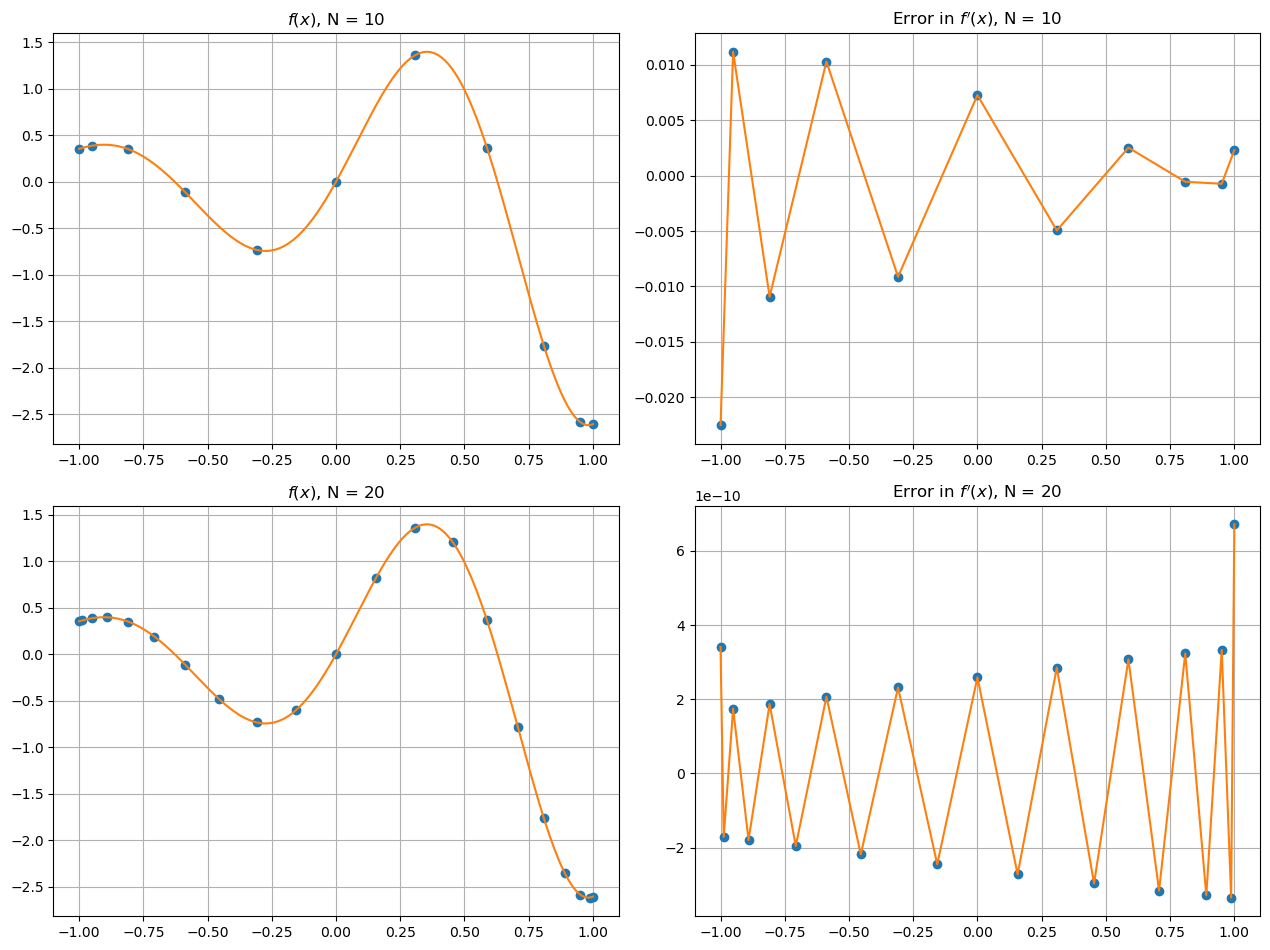

In [22]:
import numpy as np                                      # import numpy
import matplotlib.pyplot as plt                         # import matplotlib

f = lambda x: np.exp(x) * np.sin(5.0 * x)               # fungsi f(x)
f_prime = lambda x: np.exp(x) * (np.sin(5.0 * x) + 5.0 * np.cos(5.0 * x))  # turunan eksak

x_fine = np.linspace(-1, 1, 400)                        # grid halus

fig, axes = plt.subplots(2, 2)                          # buat subplot 2x2
fig.set_figwidth(fig.get_figwidth() * 2)                # perbesar lebar
fig.set_figheight(fig.get_figheight() * 2)              # perbesar tinggi

for i, N in enumerate((10, 20)):                        # loop untuk N = 10 dan 20
    x = np.cos(np.pi * np.arange(N + 1) / N)            # titik Chebyshev
    
    axes[i, 0].plot(x, f(x), '.', markersize=12)        # titik interpolasi
    axes[i, 0].plot(x_fine, f(x_fine))                  # kurva asli
    axes[i, 0].grid(True)                               # grid
    axes[i, 0].set_title(f"$f(x)$, N = {N}")            # judul
    
    error = chebfft(f(x)) - f_prime(x)                  # error turunan
    axes[i, 1].plot(x, error, '.', markersize=12)       # plot titik error
    axes[i, 1].plot(x, error)                           # garis error
    axes[i, 1].grid(True)                               # grid
    axes[i, 1].set_title(f"Error in $f'(x)$, N = {N}")  # judul

plt.tight_layout()                                      # rapikan layout
plt.show()                                              # tampilkan plot

Kita juga dapat menerapkan metode ini untuk menyelesaikan PDE dengan menggunakan metode spektral Chebyshev pada arah spasial dan diskretisasi waktu pada arah waktu. Pertimbangkan persamaan gelombang orde dua berikut:

$$
u_{tt} = u_{xx}
$$

pada domain $\Omega = [-1, 1]$ dengan kondisi batas bernilai nol. Untuk integrasi waktu, kita kembali menggunakan metode *leapfrog*.

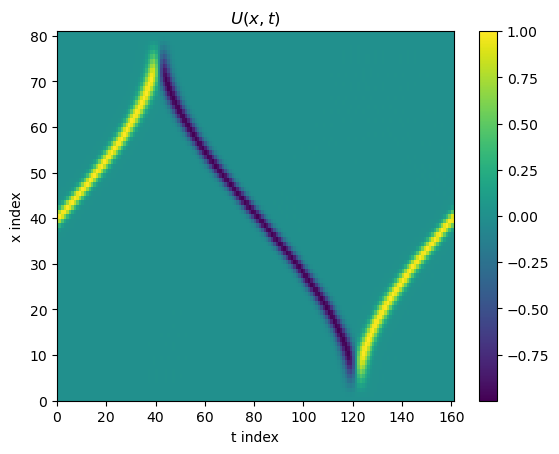

In [23]:
import numpy as np                                      # import numpy
import matplotlib.pyplot as plt                         # import matplotlib

# asumsi chebfft sudah didefinisikan sebelumnya

N = 80                                                  # jumlah grid
x = np.cos(np.pi * np.arange(0, N + 1) / N)             # titik Chebyshev

delta_t = 8.0 / N**2                                    # langkah waktu (stabil)
U = np.exp(-200.0 * x**2)                               # kondisi awal
U_old = np.exp(-200.0 * (x - delta_t)**2)               # kondisi awal t - dt
t_final = 4.0                                           # waktu akhir

num_steps = int(np.ceil(t_final / delta_t))             # jumlah langkah waktu
plot_interval = 20                                      # interval output
t = 0.0                                                 # waktu awal

num_output = int(num_steps / plot_interval) + 1         # jumlah frame output
t_output = np.empty(num_output)                         # simpan waktu
t_output[0] = 0.0                                       # waktu awal

U_output = np.empty((x.shape[0], num_output))           # simpan solusi
U_output[:, 0] = U.copy()                               # simpan kondisi awal

frame = 1                                               # indeks frame

for n in range(num_steps):                              # loop waktu
    U_xx = chebfft(chebfft(U))                          # turunan kedua (u_xx)
    U_xx[0] = 0.0                                       # boundary kiri = 0
    U_xx[-1] = 0.0                                      # boundary kanan = 0

    U_new = 2.0 * U - U_old + delta_t**2 * U_xx         # skema leapfrog
    U_old = U.copy()                                    # update U_old
    U = U_new                                           # update U

    t += delta_t                                        # update waktu

    if n % plot_interval == 0:                          # simpan tiap interval
        t_output[frame] = t                             # simpan waktu
        U_output[:, frame] = U.copy()                   # simpan solusi
        frame += 1                                      # tambah frame

fig = plt.figure()                                      # buat figure
ax = fig.add_subplot(1, 1, 1)                           # subplot

plot = ax.pcolor(U_output)                              # visualisasi matriks solusi
ax.set_xlabel("t index")                                # label waktu (index)
ax.set_ylabel("x index")                                # label posisi (index)
ax.set_title("$U(x,t)$")                                # judul

fig.colorbar(plot)                                      # colorbar
plt.show()                                              # tampilkan plot

## Kuadratur Spektral

Salah satu konsekuensi paling kuat dari apa yang telah kita lakukan sebenarnya terlihat melalui integral. Karena integral merupakan operasi yang bersifat *smoothing*, mungkin tidak terlalu mengejutkan bahwa hal ini terjadi.

Jika kita ingin mendekati integral:

$$
I = \int_{-1}^{1} f(x)\, dx
$$

salah satu cara adalah dengan mencari polinomial interpolasi dari $f(x)$, lalu mengintegralkan polinomial tersebut. Metode ini dikenal sebagai **kuadratur Clenshaw-Curtis** dan memiliki orde optimal pada himpunan titik Chebyshev tetap.

Kita akan mengikuti proses yang sebelumnya digunakan untuk menghubungkan FFT dengan deret Chebyshev, sehingga diperoleh:

$$
\begin{aligned}
\int_{-1}^{1} p(x)\, dx &= \int_{-1}^{1} p(z)\, \frac{dx}{dz}\, dz \\
&= \frac{1}{4} \sum_{n=0}^{N} a_n \int_{-1}^{1} (z^n + z^{-n})(1 - z^{-2})\, dz \\
&= \frac{1}{4} \sum_{n=0}^{N} a_n \int_{-1}^{1} (z^n - z^{n-2} + z^{-n} - z^{-n-2})\, dz \\
&= \frac{1}{4} \sum_{n=0}^{N} a_n \left(
\left. \frac{z^{n+1} + z^{-n-1}}{n+1} \right|_{-1}^{1}
- 
\left. \frac{z^{n-1} + z^{-n+1}}{n-1} \right|_{-1}^{1}
\right) \\
&= \sum_{\substack{n=0 \\ n\ \text{genap}}}^{N} a_n 
\left( \frac{1}{n+1} - \frac{1}{n-1} \right) \\
&= \sum_{\substack{n=0 \\ n\ \text{genap}}}^{N} \frac{2a_n}{1 - n^2}.
\end{aligned}
$$

Dengan hasil ini, kita dapat menggunakan FFT untuk menentukan koefisien $a_n$ seperti yang telah dijelaskan sebelumnya.

In [24]:
import numpy as np                                      # import numpy

def cheb_diff(N):                                       # fungsi inverse diferensiasi Chebyshev
    D, x = cheb(N)                                      # hitung matriks diferensiasi & grid
    D_inv = np.linalg.inv(D[:-1, :-1])                   # inverse (tanpa titik terakhir)
    x = x[:-1]                                          # hapus titik terakhir (boundary)

    return D_inv, x                                     # kembalikan inverse & grid

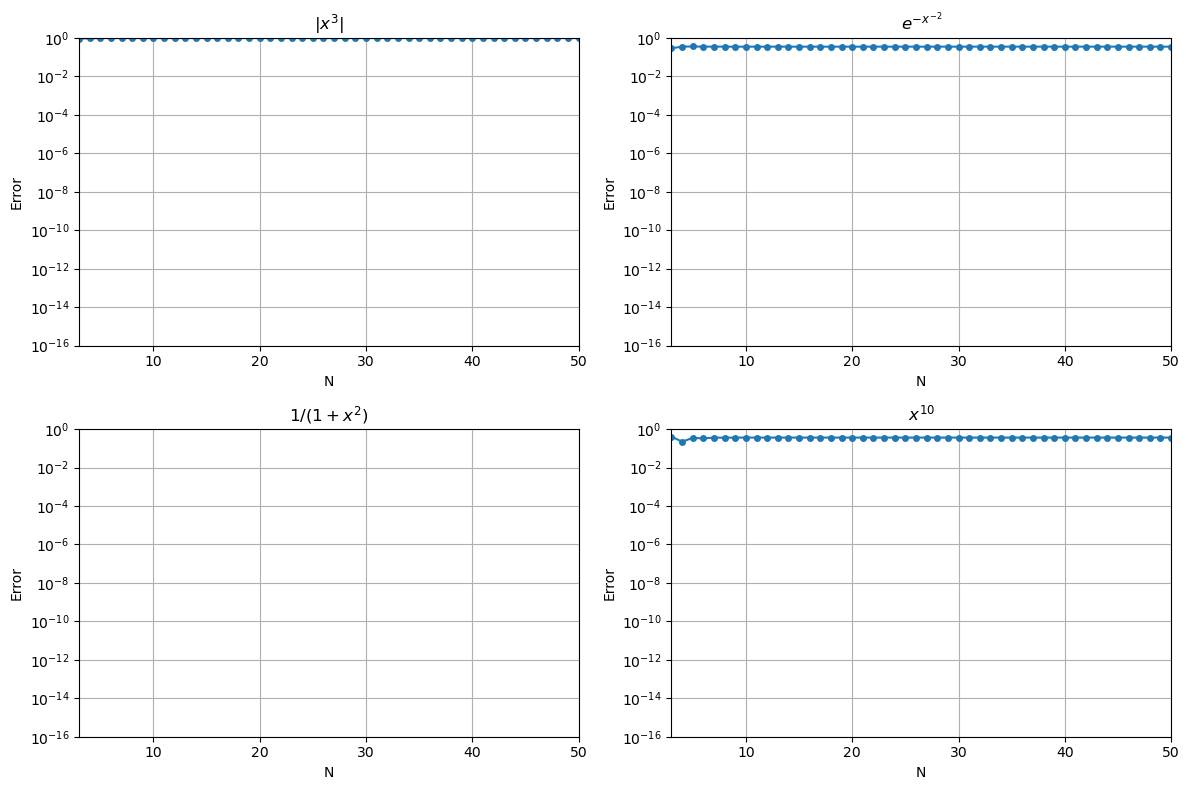

In [29]:
import numpy as np                                      # numpy
import matplotlib.pyplot as plt                         # matplotlib
import scipy.special as sp                              # special functions

N_max = 50                                              # maksimum N
error = np.zeros((4, N_max - 2))                        # array error
N_range = np.arange(3, N_max + 1)                       # range N

for i, N in enumerate(N_range):                         # loop N
    D_inv, x = cheb_diff(N)                             # inverse matrix

    # |x|^3
    f = np.abs(x)**3
    f_int = 0.5
    error[0, i] = abs(D_inv[0, :] @ f - f_int)

    # exp(-x^-2)
    f = np.exp(-x**(-2))
    f_int = 2.0 * (np.exp(-1) + np.sqrt(np.pi) * (sp.erf(1) - 1))
    error[1, i] = abs(D_inv[0, :] @ f - f_int)

    # 1/(1+x^2)
    f = 1.0 / (1.0 + x**2)
    f_int = np.pi / 2.0
    error[2, i] = abs(D_inv[0, :] @ f - f_int)

    # x^10
    f = x**10
    f_int = 2.0 / 11.0
    error[3, i] = abs(D_inv[0, :] @ f - f_int)

# Hindari nol (penting!)
error = np.maximum(error, 1e-16)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

titles = ['$|x^3|$', '$e^{-x^{-2}}$', '$1/(1+x^2)$', '$x^{10}$']

for i, ax in enumerate(axes.flat):
    ax.semilogy(N_range, error[i], 'o-', markersize=4)  # lebih clean
    ax.set_xlim(3, N_max)
    ax.set_ylim(1e-16, 1e0)                             # penting: zoom!
    ax.grid(True)
    ax.set_xlabel("N")
    ax.set_ylabel("Error")
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

In [32]:
import numpy as np                                      # import numpy

def clencurt(N):                                        # Clenshaw-Curtis quadrature
    if N == 0:                                          # kasus trivial
        return np.array([2.0]), np.array([0.0])         # integral langsung

    theta = np.pi * np.arange(N + 1) / N                # theta grid
    x = np.cos(theta)                                   # titik Chebyshev
    w = np.zeros(N + 1)                                 # bobot
    v = np.ones(N - 1)                                  # helper vector

    if N % 2 == 0:                                      # jika N genap
        w[0] = 1.0 / (N**2 - 1.0)                       # bobot ujung
        w[-1] = w[0]

        for k in range(1, N // 2):                      # mulai dari 1 (hindari div 0)
            v -= 2.0 * np.cos(2 * k * theta[1:-1]) / (4 * k**2 - 1)

        v -= np.cos(N * theta[1:-1]) / (N**2 - 1.0)     # term terakhir

    else:                                               # jika N ganjil
        w[0] = 1.0 / N**2
        w[-1] = w[0]

        for k in range(1, (N - 1)//2 + 1):              # loop aman
            v -= 2.0 * np.cos(2 * k * theta[1:-1]) / (4 * k**2 - 1)

    w[1:-1] = 2.0 * v / N                              # isi bagian dalam

    return w, x                                         # return weights & nodes

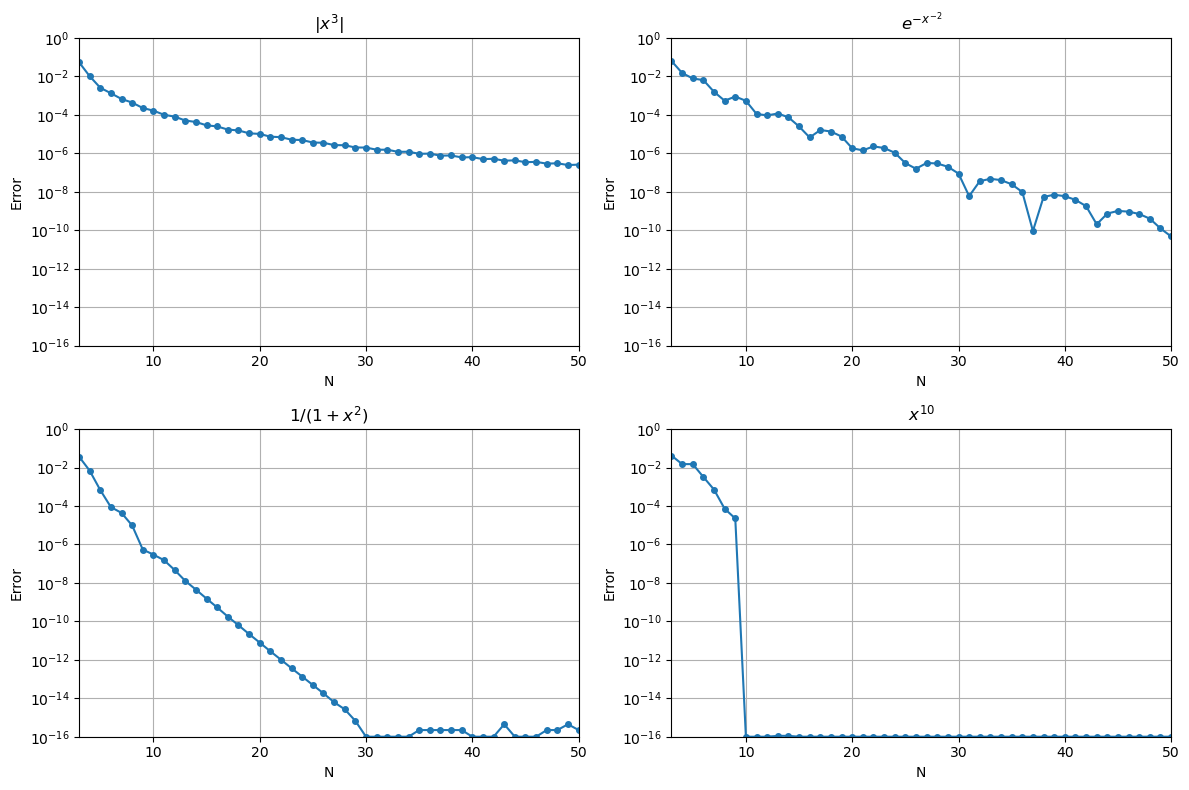

In [33]:
import numpy as np                                      # numpy
import matplotlib.pyplot as plt                         # matplotlib
import scipy.special as sp                              # special functions

N_max = 50                                              # maksimum N
error = np.zeros((4, N_max - 2))                        # array error
N_range = np.arange(3, N_max + 1)                       # range N

for i, N in enumerate(N_range):                         # loop N
    w, x = clencurt(N)                                  # weights & nodes

    f = np.abs(x)**3                                    # fungsi 1
    f_int = 0.5
    error[0, i] = abs(np.dot(w, f) - f_int)

    f = np.exp(-x**(-2))                                # fungsi 2
    f_int = 2.0 * (np.exp(-1) + np.sqrt(np.pi) * (sp.erf(1) - 1))
    error[1, i] = abs(np.dot(w, f) - f_int)

    f = 1.0 / (1.0 + x**2)                              # fungsi 3
    f_int = np.pi / 2.0
    error[2, i] = abs(np.dot(w, f) - f_int)

    f = x**10                                           # fungsi 4
    f_int = 2.0 / 11.0
    error[3, i] = abs(np.dot(w, f) - f_int)

# hindari nol (WAJIB untuk log plot)
error = np.maximum(error, 1e-16)

# plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

titles = ['$|x^3|$', '$e^{-x^{-2}}$', '$1/(1+x^2)$', '$x^{10}$']

for i, ax in enumerate(axes.flat):
    ax.semilogy(N_range, error[i], 'o-', markersize=4)
    ax.set_xlim(3, N_max)
    ax.set_ylim(1e-16, 1e0)                             # zoom penting!
    ax.grid(True)
    ax.set_xlabel("N")
    ax.set_ylabel("Error")
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

In [34]:
import numpy as np                                      # import numpy

def gauss(N):                                           # Gauss-Legendre quadrature
    beta = 0.5 / np.sqrt(1.0 - (2.0 * np.arange(1, N))**(-2))  # koefisien off-diagonal

    T = np.diag(beta, 1) + np.diag(beta, -1)            # matriks tridiagonal simetris

    x, V = np.linalg.eigh(T)                            # eigenvalue (lebih stabil dari eig)

    w = 2.0 * (V[0, :]**2)                              # bobot quadrature

    return w, x                                         # return weights & nodes

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17396\181407042.py:16: RuntimeWarning: divide by zero encountered in power
  f = np.exp(-x**(-2))                                # fungsi 2


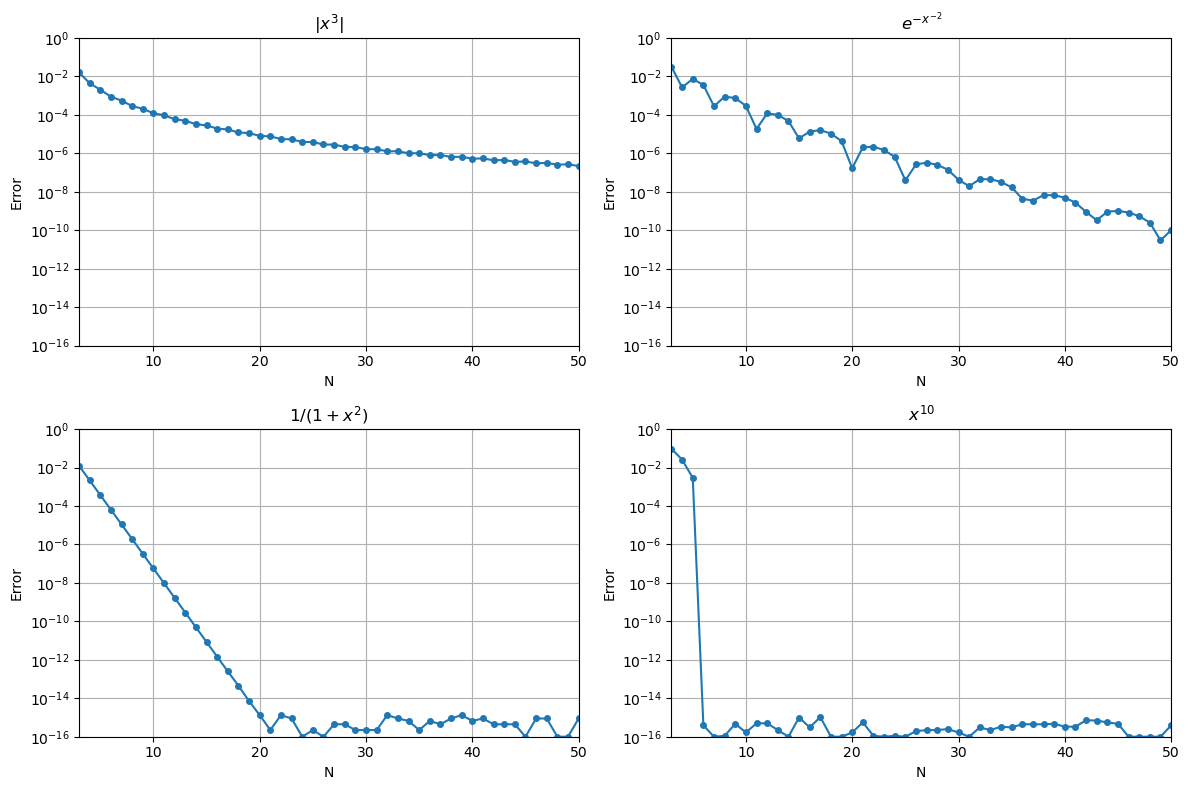

In [35]:
import numpy as np                                      # numpy
import matplotlib.pyplot as plt                         # matplotlib
import scipy.special as sp                              # special functions

N_max = 50                                              # maksimum N
error = np.zeros((4, N_max - 2))                        # array error
N_range = np.arange(3, N_max + 1)                       # range N

for i, N in enumerate(N_range):                         # loop N
    w, x = gauss(N)                                     # Gauss-Legendre

    f = np.abs(x)**3                                    # fungsi 1
    f_int = 0.5
    error[0, i] = abs(np.dot(w, f) - f_int)

    f = np.exp(-x**(-2))                                # fungsi 2
    f_int = 2.0 * (np.exp(-1) + np.sqrt(np.pi) * (sp.erf(1) - 1))
    error[1, i] = abs(np.dot(w, f) - f_int)

    f = 1.0 / (1.0 + x**2)                              # fungsi 3
    f_int = np.pi / 2.0
    error[2, i] = abs(np.dot(w, f) - f_int)

    f = x**10                                           # fungsi 4
    f_int = 2.0 / 11.0
    error[3, i] = abs(np.dot(w, f) - f_int)

# Hindari nol (WAJIB untuk log plot)
error = np.maximum(error, 1e-16)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

titles = ['$|x^3|$', '$e^{-x^{-2}}$', '$1/(1+x^2)$', '$x^{10}$']

for i, ax in enumerate(axes.flat):
    ax.semilogy(N_range, error[i], 'o-', markersize=4)
    ax.set_xlim(3, N_max)
    ax.set_ylim(1e-16, 1e0)                             # zoom penting!
    ax.grid(True)
    ax.set_xlabel("N")
    ax.set_ylabel("Error")
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()